In [4]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../')
# from src import utils, RWSampler
# import Inference as inf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import ee
ee.Initialize()
from geetools import batch

In [12]:
from sentinelsat import SentinelAPI
import geopandas as gpd

# def download_sentinel_images(shapefile_path, date_start, date_end, output_folder, satellite="Sentinel-2", max_cloud=5):
#     """
#     Download Sentinel satellite images based on geometry from a shapefile, date range, and cloud cover.
    
#     Args:
#     - username (str): Username for the API service.
#     - password (str): Password for the API service.
#     - shapefile_path (str): Path to the shapefile defining the area of interest.
#     - date_start (str): Start date in 'YYYYMMDD' format.
#     - date_end (str): End date in 'YYYYMMDD' format.
#     - output_folder (str): Folder path where the downloaded images will be stored.
#     - satellite (str): Specify "Sentinel-1" or "Sentinel-2" for different satellites.
#     - max_cloud (float): Maximum cloud cover percentage allowed for the images.
    
#     Returns:
#     - None
# """
# Initialize the API
api = SentinelAPI('hkamangir@ucdavis.edu', '21#Kaman#1987', 'https://apihub.copernicus.eu/apihub', timeout=100)

In [13]:
shapefile_path = '/data2/hkaman/Data/Livingston/shp/Livingston_boundaries.shp'
# Load the shapefile and convert to WKT
gdf = gpd.read_file(shapefile_path)
# Assuming the shapefile contains one geometry, extract the first
footprint = gdf['geometry'].to_wkt()[0]

satellite = 'Sentinel-2'
# Define the product type and extra parameters based on satellite
if satellite == "Sentinel-1":
    product_type = 'GRD'  # Ground Range Detected
    query_kwargs = {}
elif satellite == "Sentinel-2":
    product_type = 'S2MSI1C'  # Level-1C product
    query_kwargs = {'cloudcoverpercentage': (0, 5)}

In [14]:
# Search for products
products = api.query(footprint,
                        date=('20200101', '20200131'),
                        platformname=satellite,
                        producttype=product_type,
                        **query_kwargs)

# Download all products
api.download_all(products, directory_path='/home/hkaman/Documents/multimodel-transformers-vye/notebooks/data/')

ConnectTimeout: HTTPSConnectionPool(host='apihub.copernicus.eu', port=443): Max retries exceeded with url: /apihub/search?format=json&rows=100&start=0&q=beginPosition%3A%5B%222020-01-01T00%3A00%3A00Z%22+TO+%222020-01-31T00%3A00%3A00Z%22%5D+cloudcoverpercentage%3A%5B%220%22+TO+%225%22%5D+platformname%3A%22Sentinel-2%22+producttype%3A%22S2MSI1C%22+footprint%3A%22Intersects%28POLYGON+%28%28-74318.4905+-71836.3543%2C+-74279.2812+-71815.906%2C+-74244.5456+-71799.9655%2C+-74223.6215+-71788.64%2C+-74180.8788+-71767.7133%2C+-74171.4069+-71763.2875%2C+-74134.496+-71754.535%2C+-74085.0657+-71744.6763%2C+-74044.0094+-71735.789%2C+-74033.0252+-71732.8474%2C+-74030.7625+-71731.7153%2C+-74022.0243+-71729.0202%2C+-73980.3518+-71711.3649%2C+-73943.2963+-71695.6826%2C+-73934.9302+-71692.5194%2C+-73899.0764+-71677.4703%2C+-73891.223+-71675.1939%2C+-73862.7869+-71663.8581%2C+-73862.7184+-71668.8486%2C+-73859.605+-71668.2158%2C+-73858.8404+-71661.4832%2C+-73829.6105+-71650.5716%2C+-73807.8202+-71641.7989%

### Others

In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/data2/hkaman/Data/Coords/S2/BHO/train.csv', index_col=0)
df.reset_index(inplace = True, drop = True)
df

,block,cultivar,cultivar_id,trellis,trellis_id,row,space,patch_mean,year,X,...,block_std,win_block_mean,win_block_std,win_cultivar_mean,win_cultivar_std,weight,NormWeight,MET_PATH,TEXT_PATH,S1_PATH
0,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,7.844121,2016,0,...,0.607896,8.372056,0.228445,11.190998,2.027858,0.981634,0.000645,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
1,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,9.179390,2016,0,...,0.607896,8.372056,0.228445,11.190998,2.027858,0.018366,0.000012,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
2,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,9.158307,2016,0,...,0.607896,8.372056,0.228445,11.190998,2.027858,0.018366,0.000012,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
3,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,9.121572,2016,0,...,0.607896,8.372056,0.228445,11.190998,2.027858,0.018366,0.000012,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
4,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,8.987514,2016,0,...,0.607896,8.372056,0.228445,11.190998,2.027858,0.981634,0.000645,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13870,LIV_176_2019,CHARDONNAY,3,4WIREWO,1,11,7,11.703642,2019,12,...,0.080518,12.820014,0.989606,10.629997,0.426618,0.654126,0.000544,/data2/hkaman/Data/Livingston/DayMet/LIV_176_2...,/data2/hkaman/Data/Livingston/text/LIV_176.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
13871,LIV_176_2019,CHARDONNAY,3,4WIREWO,1,11,7,11.673954,2019,14,...,0.080518,12.820014,0.989606,10.629997,0.426618,0.654126,0.000544,/data2/hkaman/Data/Livingston/DayMet/LIV_176_2...,/data2/hkaman/Data/Livingston/text/LIV_176.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
13872,LIV_176_2019,CHARDONNAY,3,4WIREWO,1,11,7,11.635944,2019,16,...,0.080518,12.820014,0.989606,10.629997,0.426618,0.654126,0.000544,/data2/hkaman/Data/Livingston/DayMet/LIV_176_2...,/data2/hkaman/Data/Livingston/text/LIV_176.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...
13873,LIV_176_2019,CHARDONNAY,3,4WIREWO,1,11,7,11.586588,2019,18,...,0.080518,12.820014,0.989606,10.629997,0.426618,0.654126,0.000544,/data2/hkaman/Data/Livingston/DayMet/LIV_176_2...,/data2/hkaman/Data/Livingston/text/LIV_176.txt,/data2/hkaman/Data/Livingston/data/10m/S1_imgs...


In [4]:
df_grouped = df.groupby(by = 'block')
group_names = list(df_grouped.groups.keys())
print(group_names)

['LIV_003_2016', 'LIV_003_2017', 'LIV_003_2018', 'LIV_003_2019', 'LIV_007_2016', 'LIV_007_2017', 'LIV_007_2018', 'LIV_007_2019', 'LIV_012_2016', 'LIV_012_2017', 'LIV_012_2018', 'LIV_012_2019', 'LIV_014_2016', 'LIV_014_2017', 'LIV_014_2018', 'LIV_014_2019', 'LIV_016_2016', 'LIV_016_2017', 'LIV_016_2018', 'LIV_016_2019', 'LIV_017_2016', 'LIV_017_2017', 'LIV_017_2018', 'LIV_018_2016', 'LIV_018_2017', 'LIV_018_2018', 'LIV_018_2019', 'LIV_038_2016', 'LIV_038_2017', 'LIV_038_2018', 'LIV_068_2016', 'LIV_068_2017', 'LIV_076_2016', 'LIV_076_2017', 'LIV_076_2018', 'LIV_076_2019', 'LIV_102_2016', 'LIV_102_2017', 'LIV_102_2018', 'LIV_102_2019', 'LIV_103_2016', 'LIV_103_2017', 'LIV_103_2018', 'LIV_103_2019', 'LIV_107_2016', 'LIV_107_2017', 'LIV_107_2018', 'LIV_107_2019', 'LIV_111_2016', 'LIV_111_2017', 'LIV_111_2018', 'LIV_111_2019', 'LIV_176_2017', 'LIV_176_2018', 'LIV_176_2019']


In [5]:
def plot_images(group):
    # Assuming 'IMG_PATH', 'S1_PATH', 'LABEL_PATH' are columns in each group


    img_path = group['IMG_PATH'].values[0]
    s1_path = group['S1_PATH'].values[0]
    label_path = group['LABEL_PATH'].values[0]
    
    # Load the images from the .npy files
    img = np.load(img_path)  # Shape should be (height, width, channels)
    s1_img = np.load(s1_path)  # Shape should be (height, width, 2)
    label_img = np.load(label_path)  # Shape should be (height, width)

    # Create a figure with subplots
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    # Plot RGB image
    axs[0].imshow(img[0, :, :, :3])
    axs[0].set_title('RGB Image')
    axs[0].axis('off')
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axs[0])
    cbar.set_label('Intensity')

    # Plot Sentinel-1 Channel 1
    s1_c1 = axs[1].imshow(s1_img[0, :, :, 0], cmap='gray')
    axs[1].set_title('S1 Channel VV')
    axs[1].axis('off')
    cbar = plt.colorbar(s1_c1, ax=axs[1])
    cbar.set_label('Intensity')

    # Plot Sentinel-1 Channel 2
    s1_c2 = axs[2].imshow(s1_img[0, :, :, 1], cmap='gray')
    axs[2].set_title('S1 Channel VH')
    axs[2].axis('off')
    cbar = plt.colorbar(s1_c2, ax=axs[2])
    cbar.set_label('Intensity')

    # Plot Label
    label = axs[3].imshow(label_img[0, :, :, 0], cmap='hot')
    axs[3].set_title('Label')
    axs[3].axis('off')
    cbar = plt.colorbar(label, ax=axs[3])
    cbar.set_label('Label Value')

    plt.tight_layout()
    plt.show()


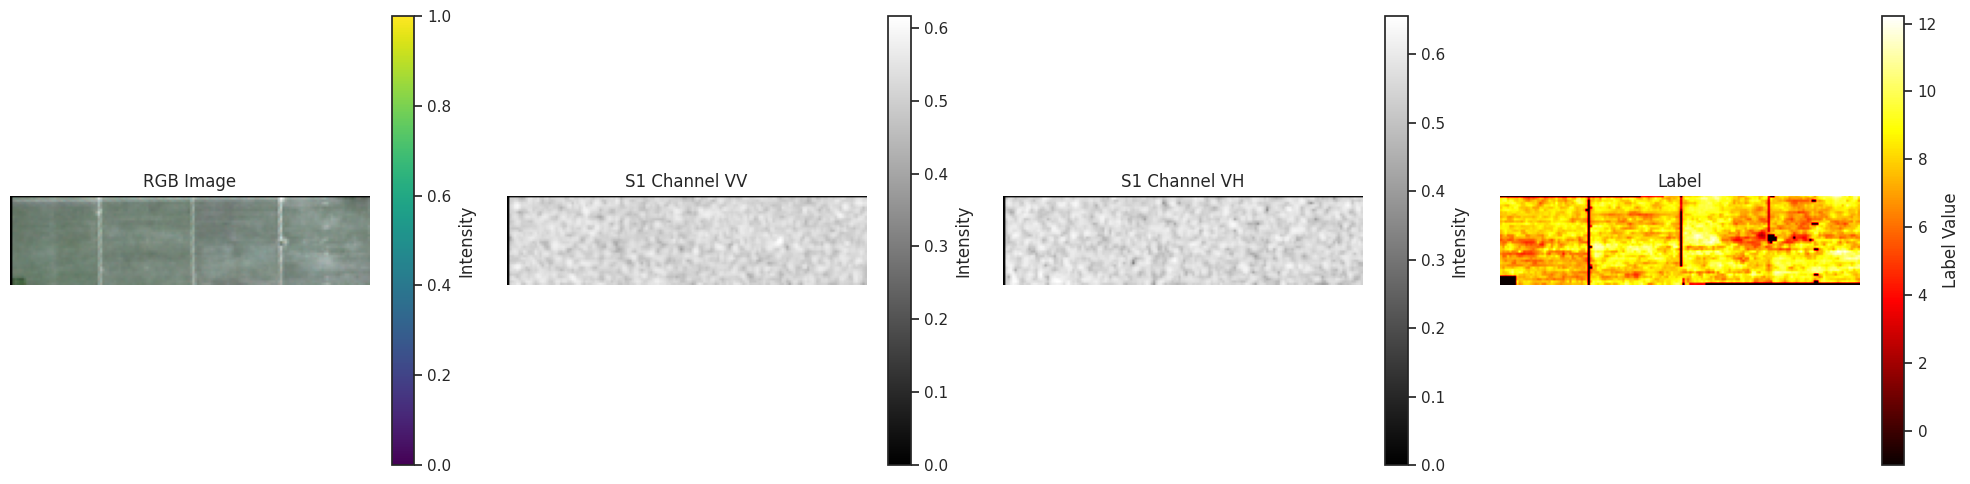

In [6]:
g = df_grouped.get_group(group_names[0])
plot_images(g)

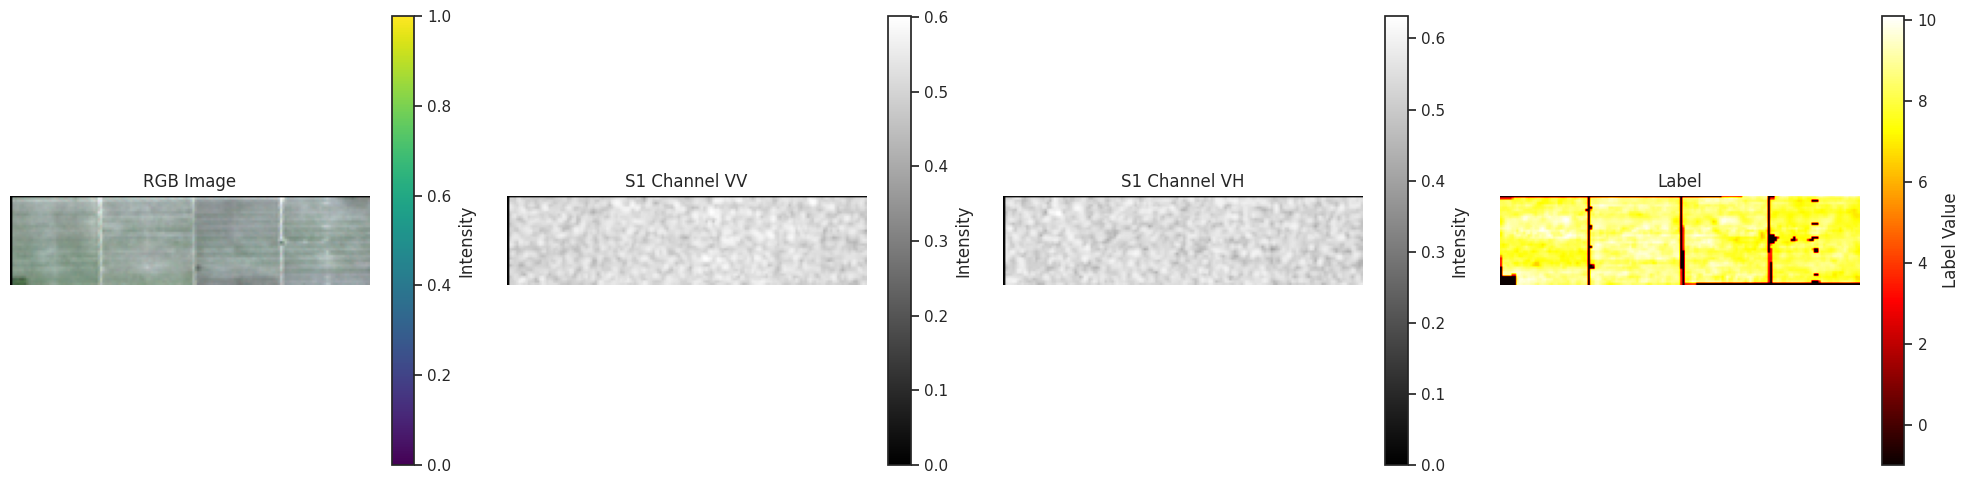

In [7]:
n1 = df_grouped.get_group(group_names[1])
plot_images(n1)

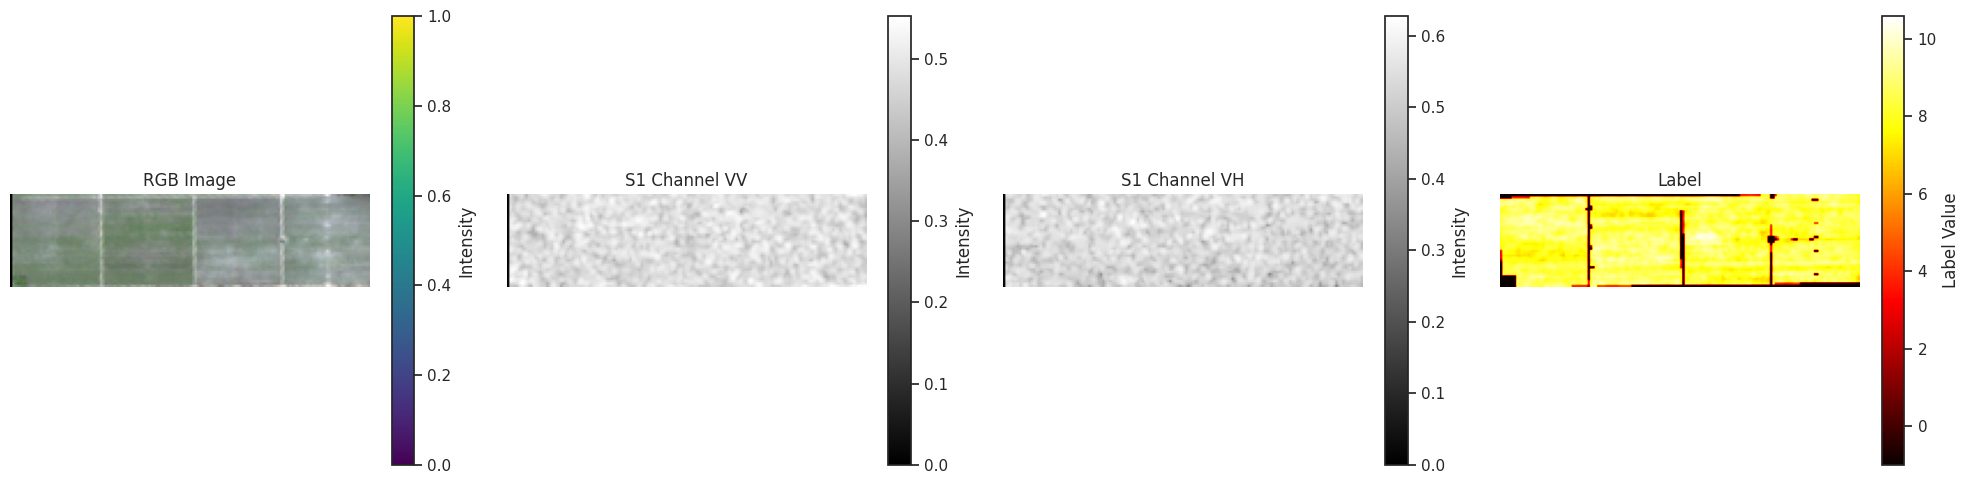

In [20]:
n2 = df_grouped.get_group(group_names[2])
plot_images(n2)

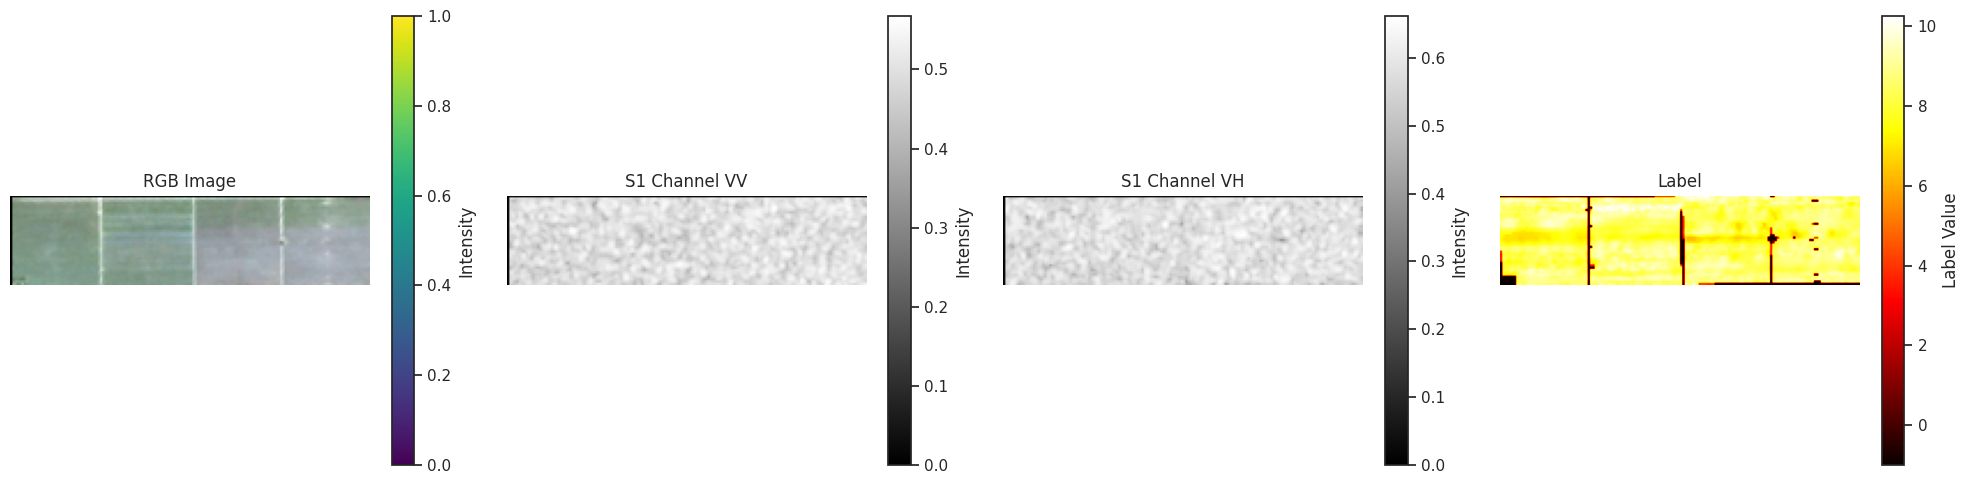

In [21]:
n1 = df_grouped.get_group(group_names[3])
plot_images(n1)

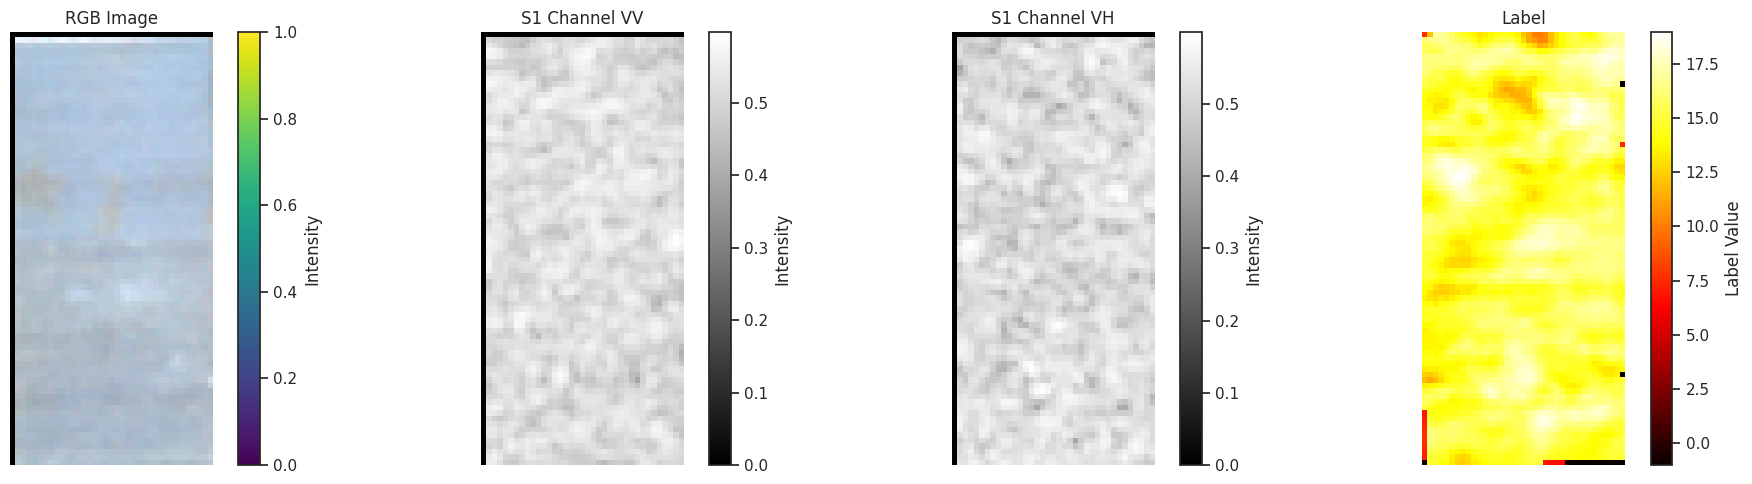

In [22]:
n4 = df_grouped.get_group(group_names[4])
plot_images(n4)

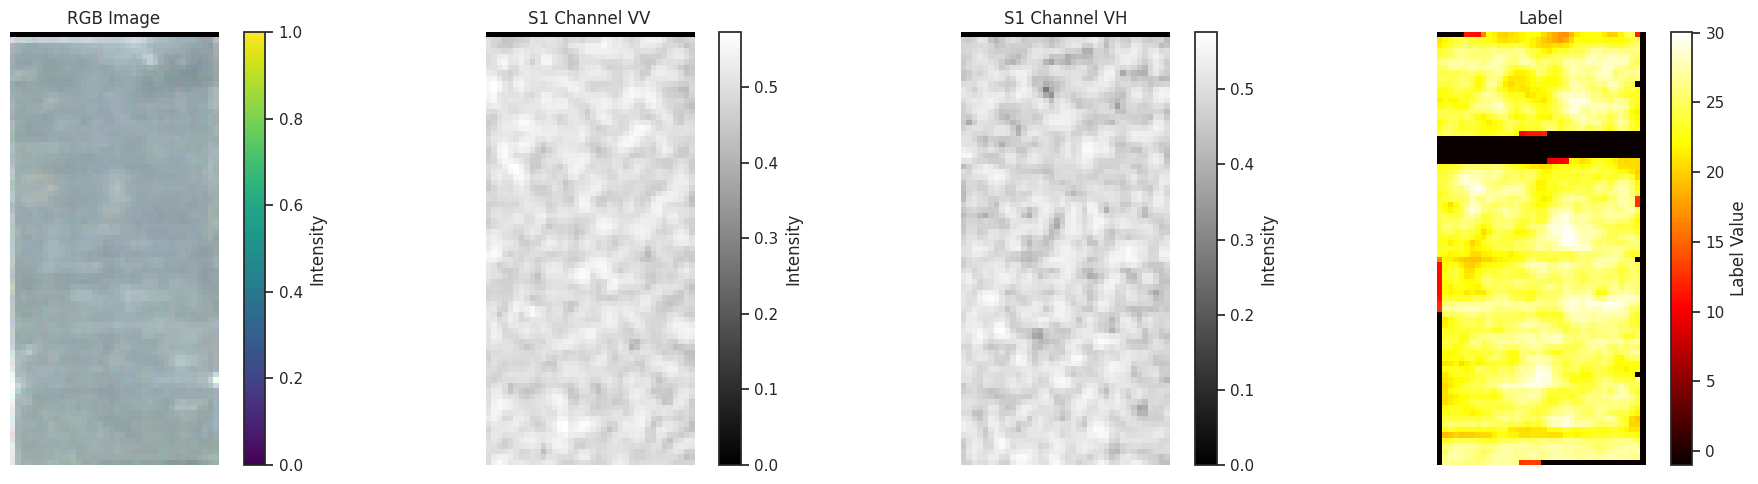

In [8]:
n5 = df_grouped.get_group(group_names[5])
plot_images(n5)

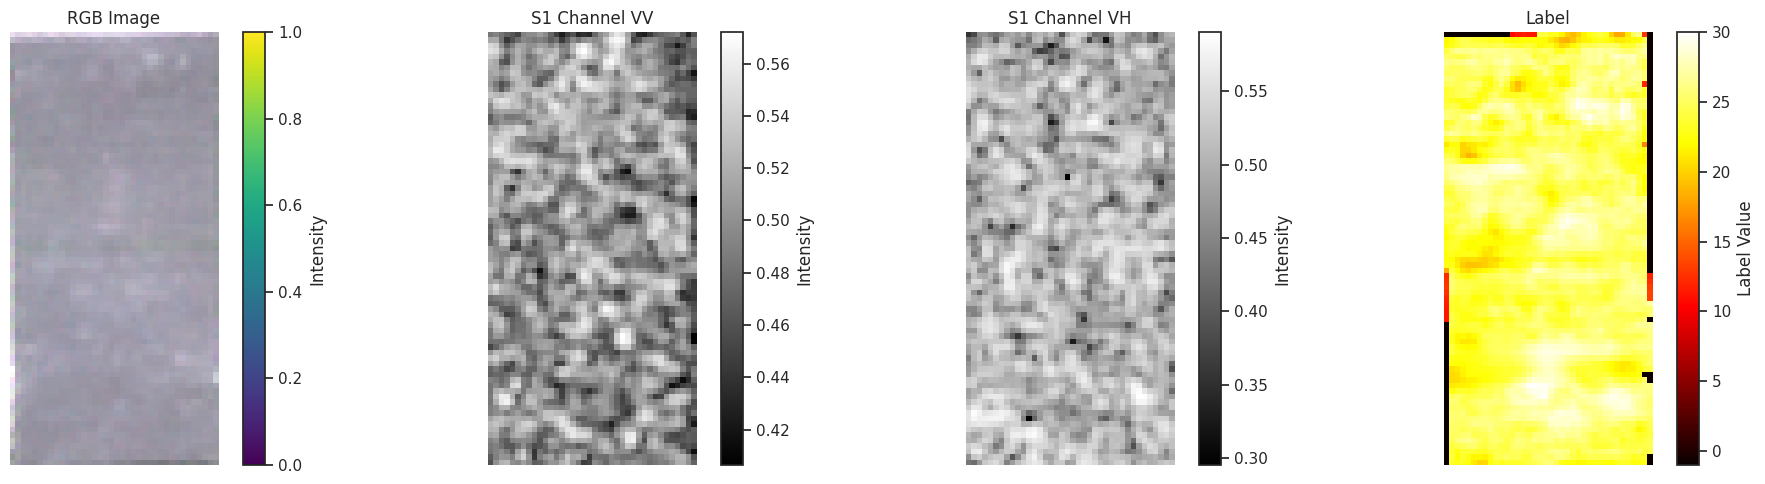

In [24]:
n6 = df_grouped.get_group(group_names[6])
plot_images(n6)

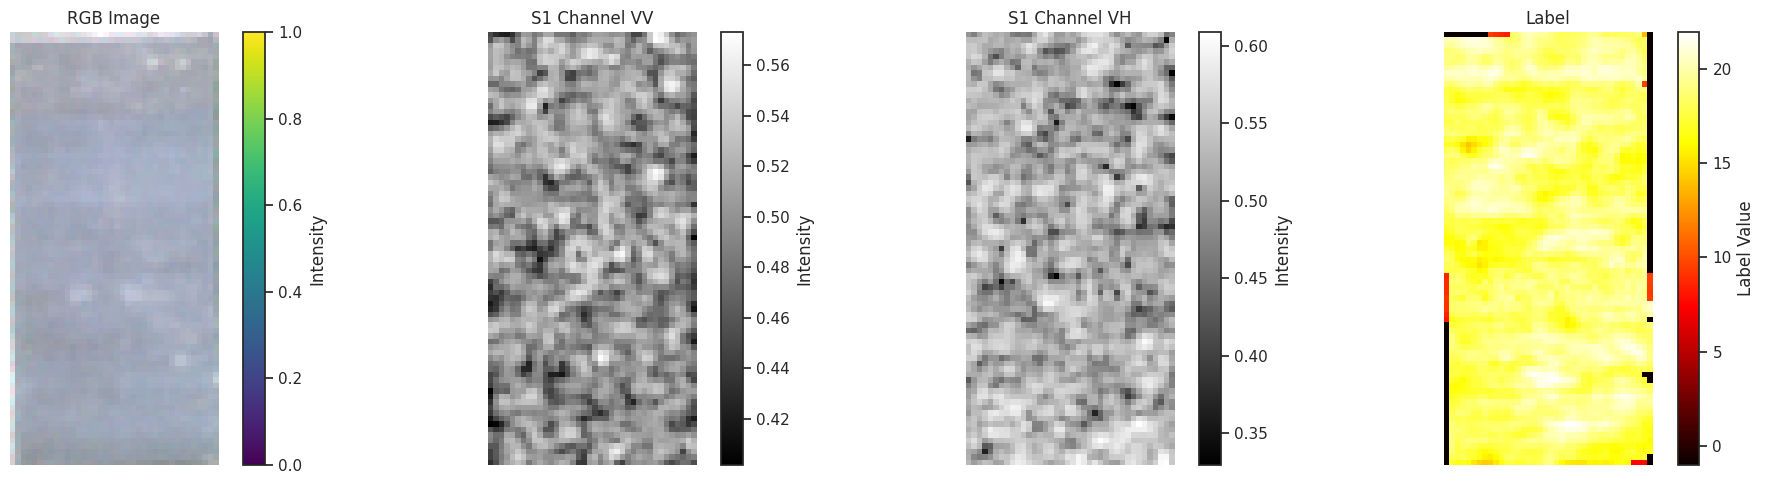

In [25]:
n7 = df_grouped.get_group(group_names[7])
plot_images(n7)

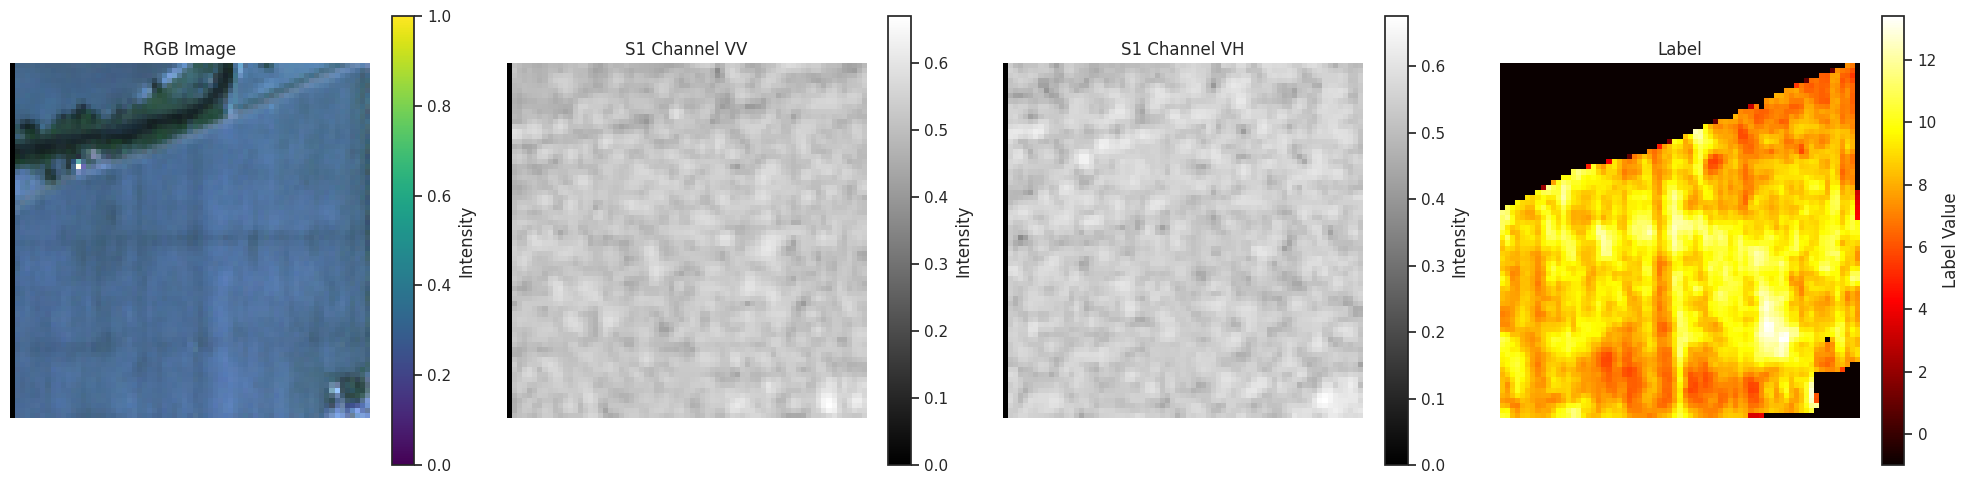

In [26]:
n8 = df_grouped.get_group(group_names[8])
plot_images(n8)

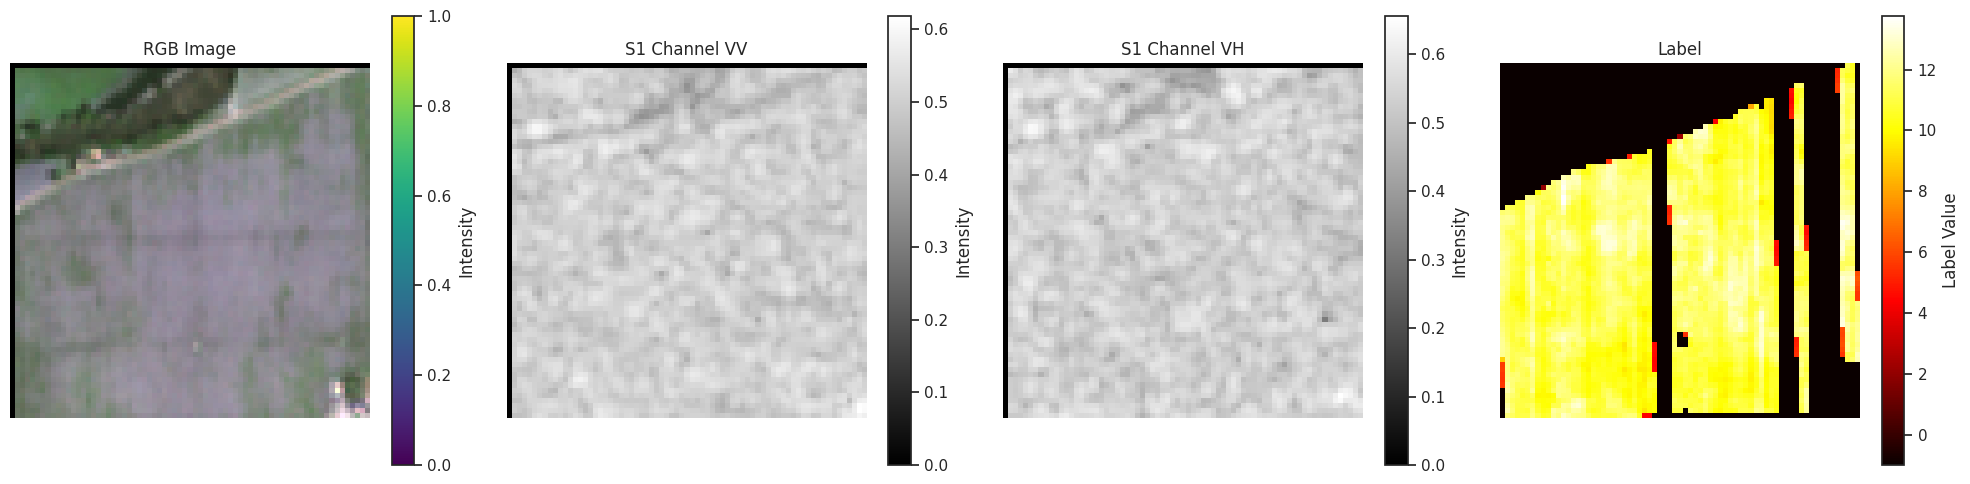

In [9]:
n9 = df_grouped.get_group(group_names[9])
plot_images(n9)

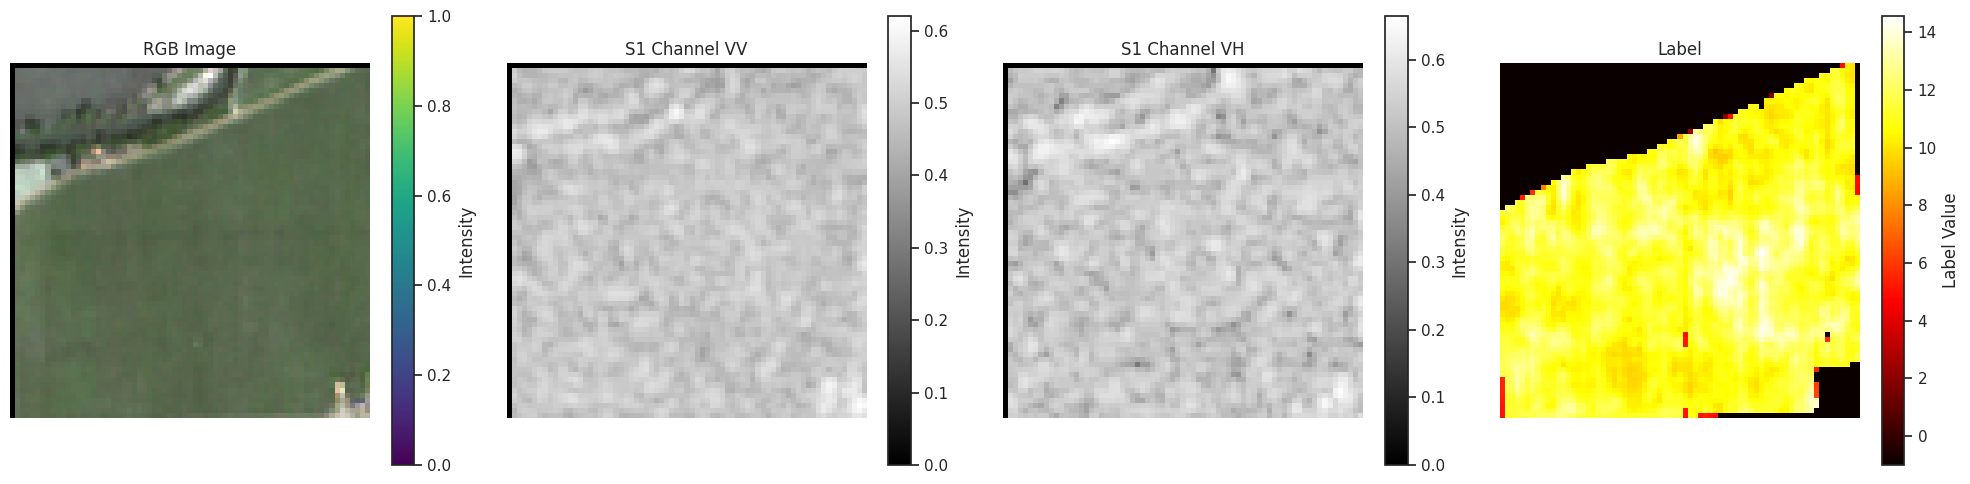

In [28]:
n10 = df_grouped.get_group(group_names[10])
plot_images(n10)

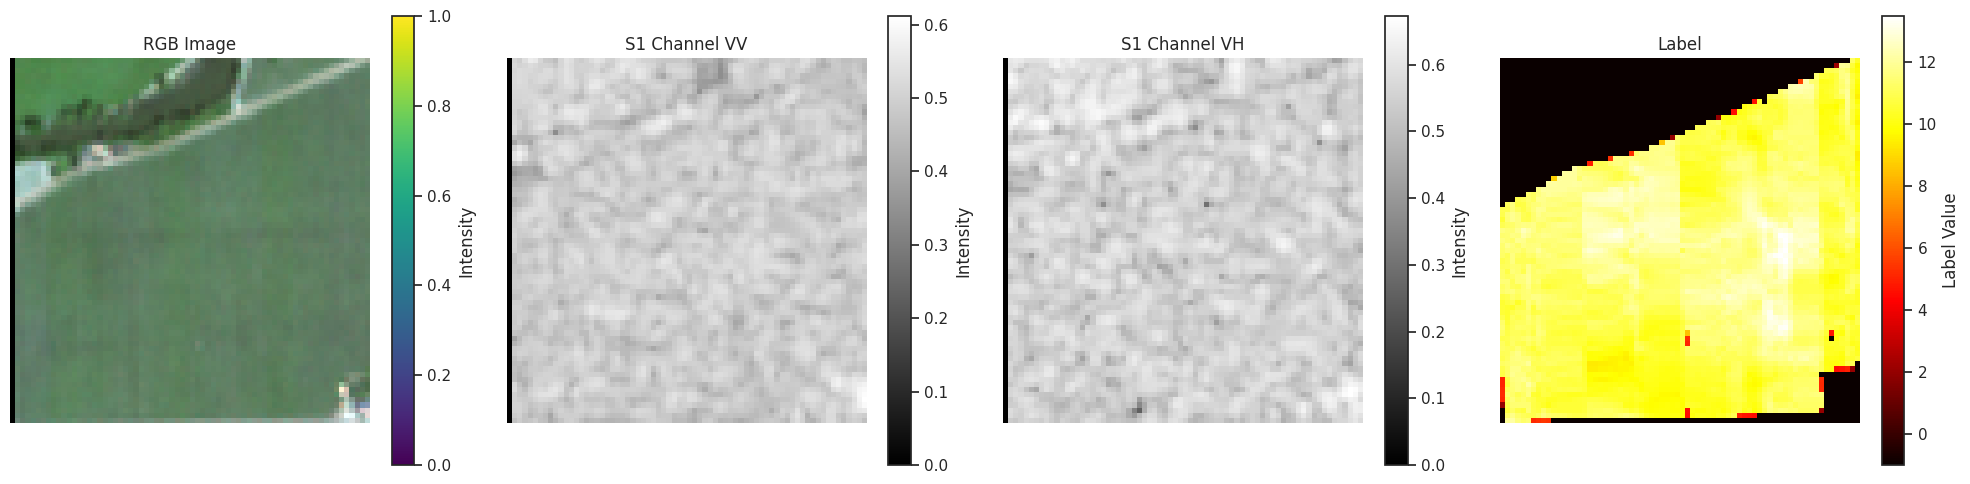

In [29]:
n11 = df_grouped.get_group(group_names[11])
plot_images(n11)

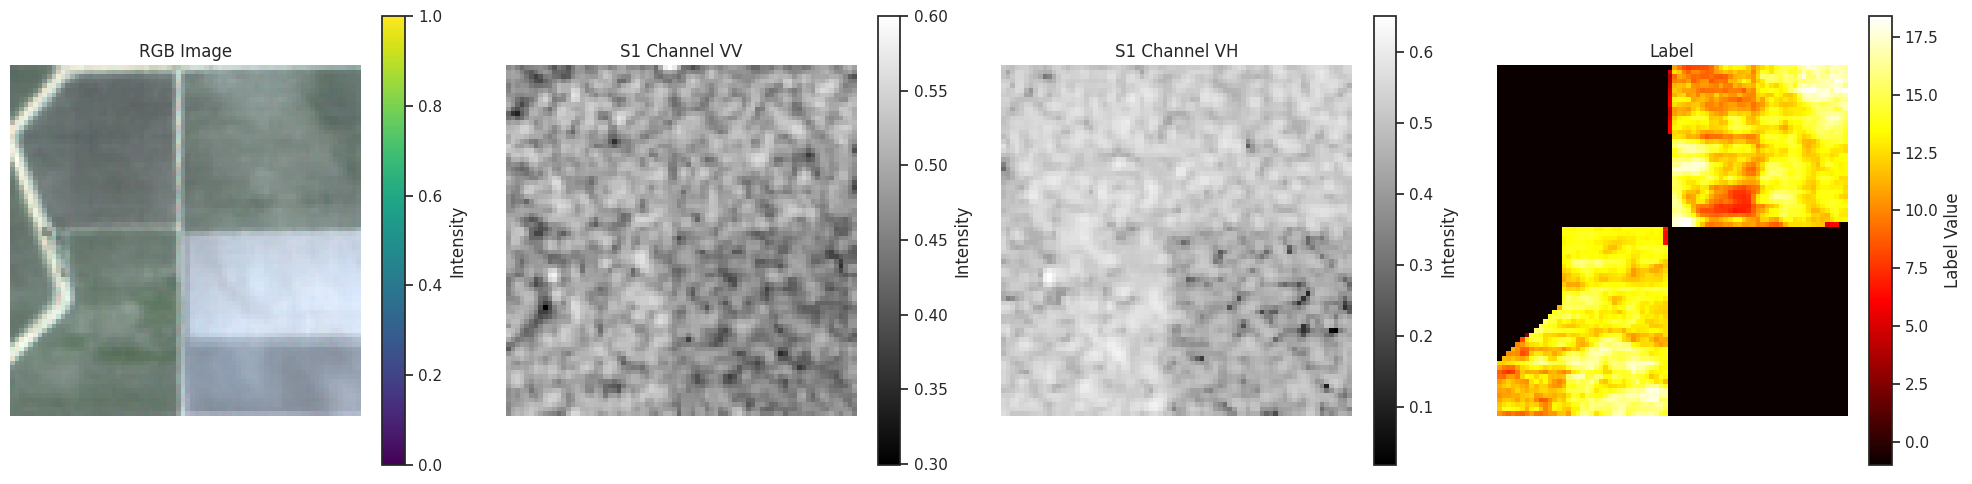

In [30]:
n12 = df_grouped.get_group(group_names[12])
plot_images(n12)

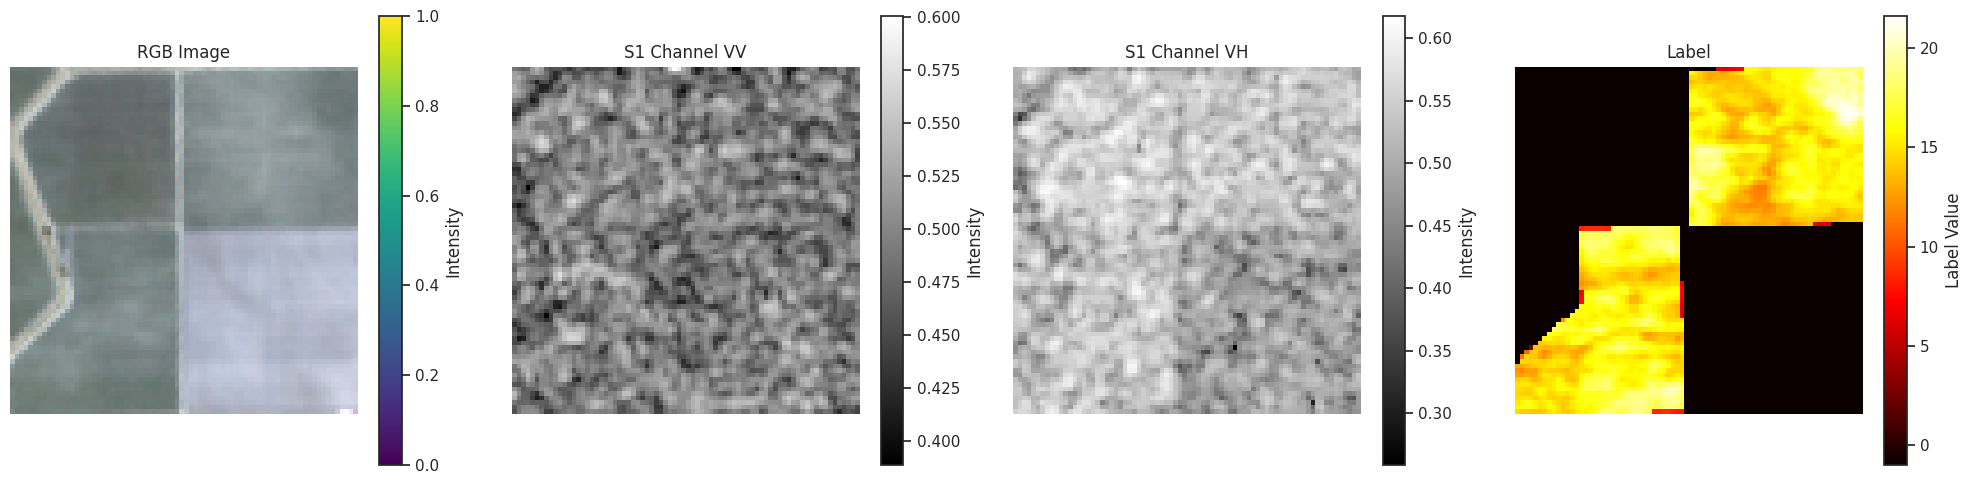

In [10]:
n13 = df_grouped.get_group(group_names[13])
plot_images(n13)

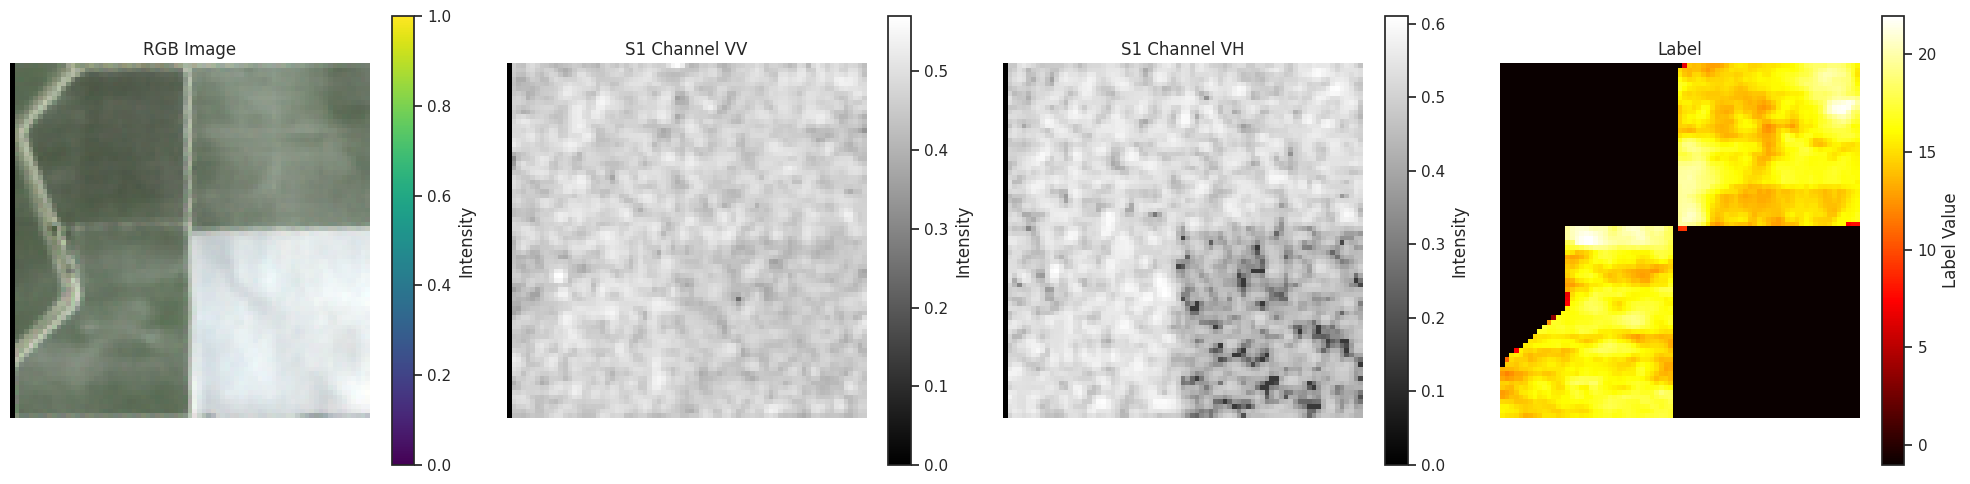

In [32]:
n14 = df_grouped.get_group(group_names[14])
plot_images(n14)

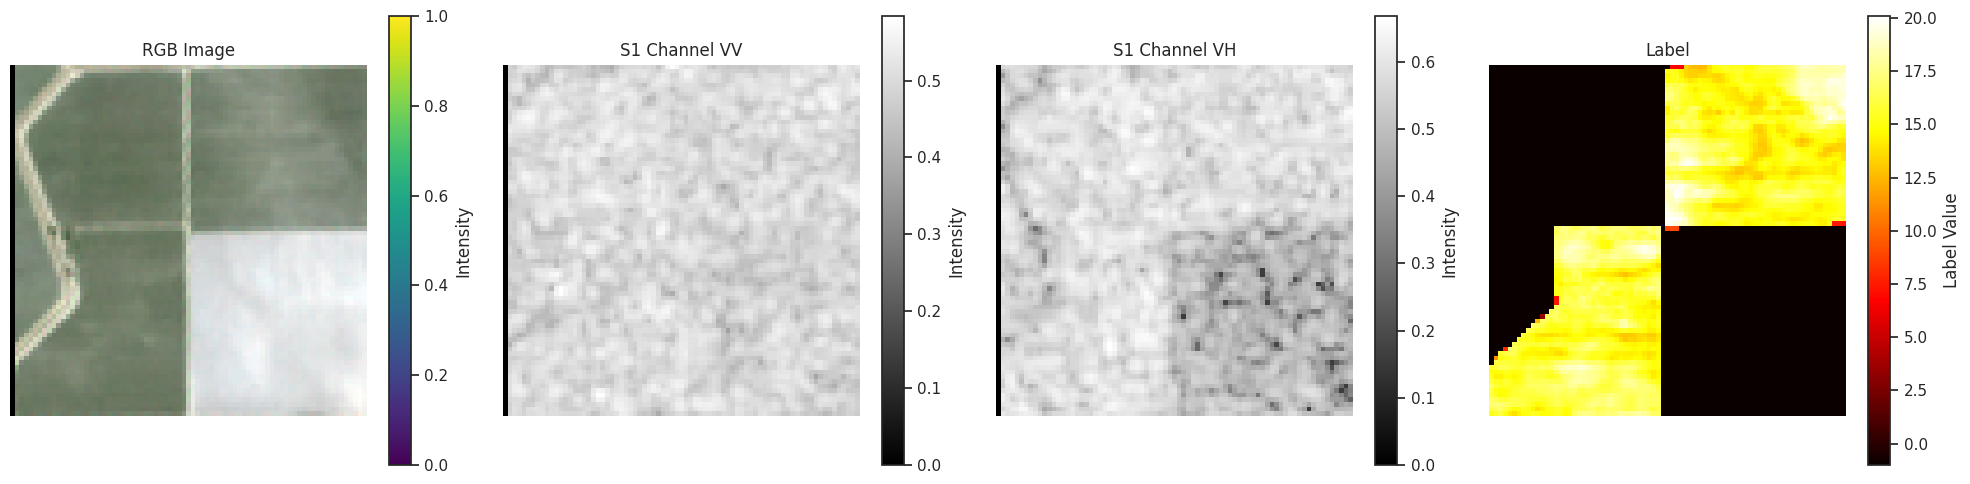

In [33]:
n15 = df_grouped.get_group(group_names[15])
plot_images(n15)

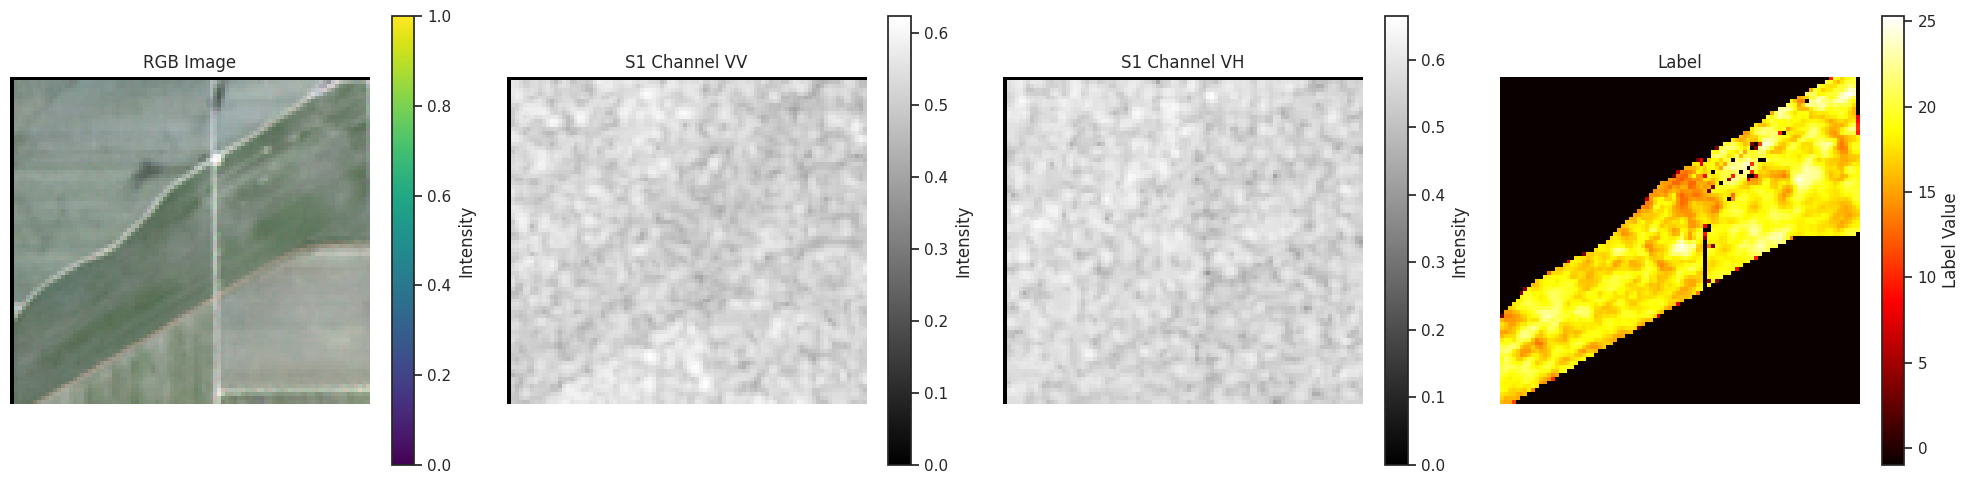

In [34]:
n16 = df_grouped.get_group(group_names[16])
plot_images(n16)

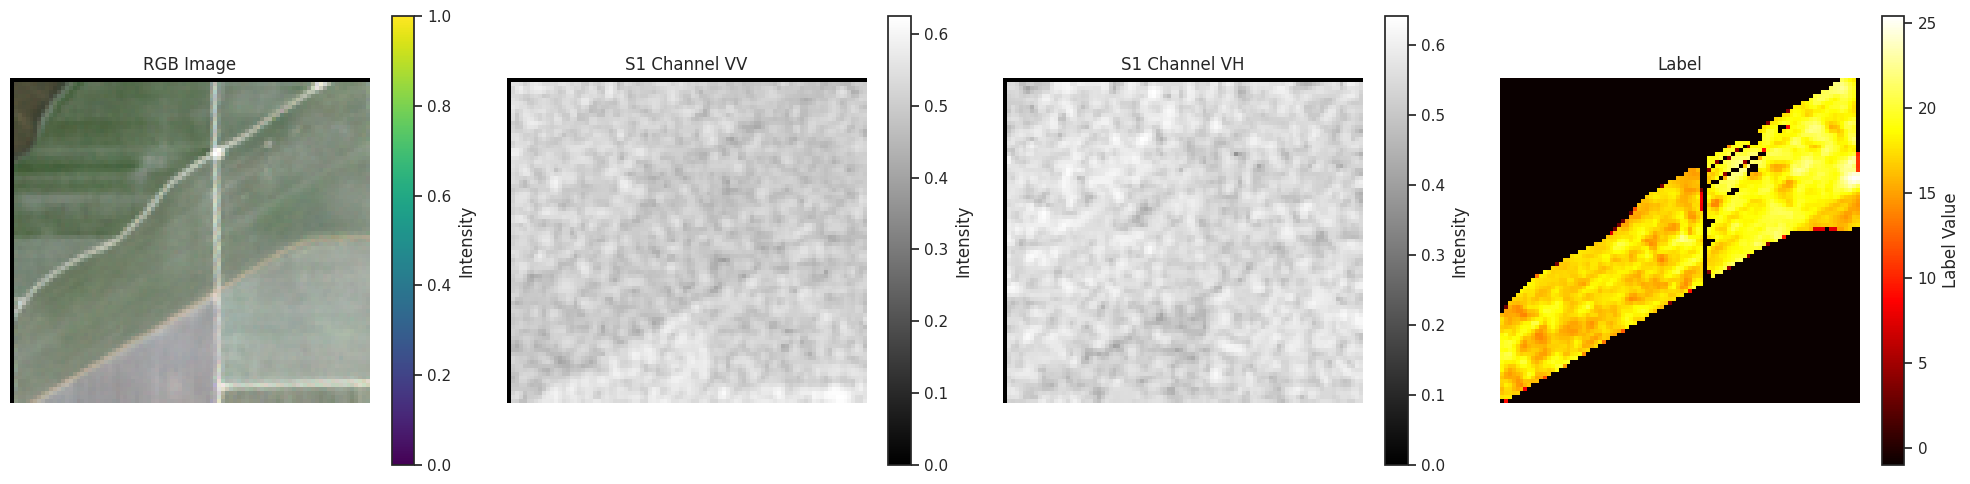

In [11]:
n17 = df_grouped.get_group(group_names[17])
plot_images(n17)

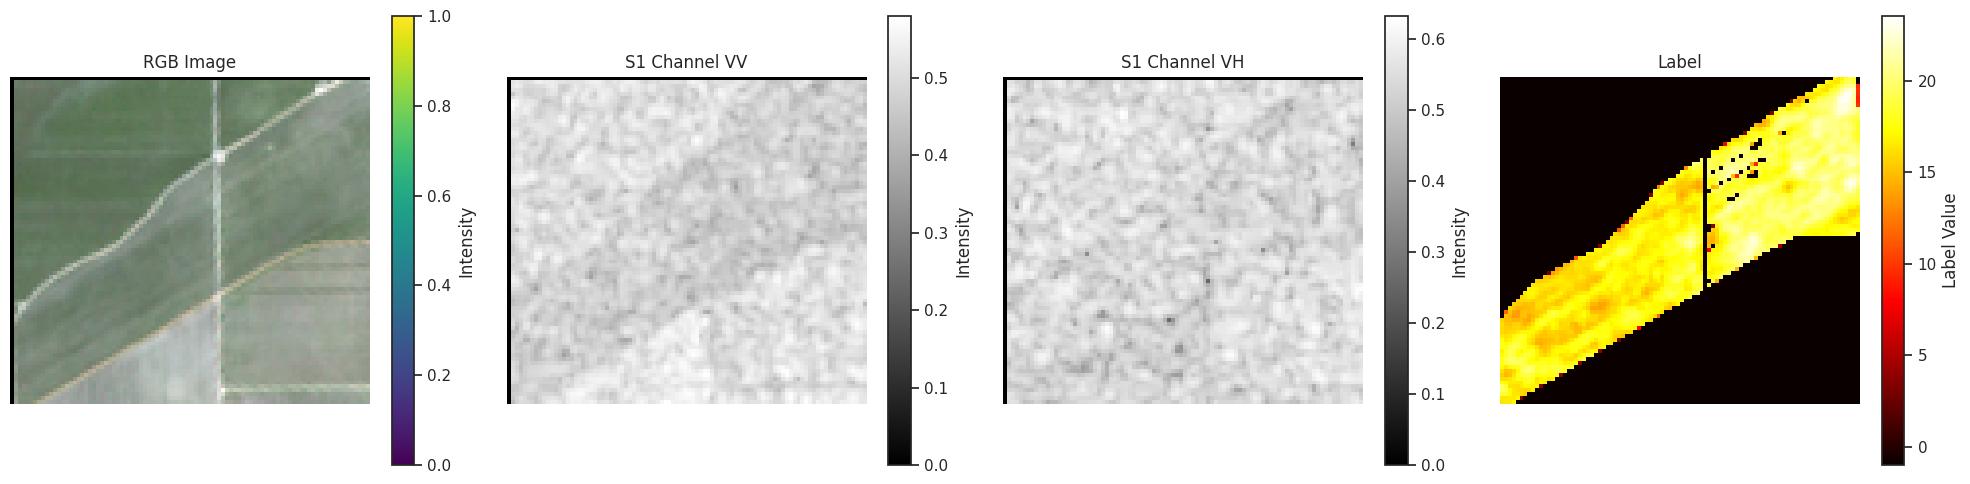

In [36]:
n18 = df_grouped.get_group(group_names[18])
plot_images(n18)

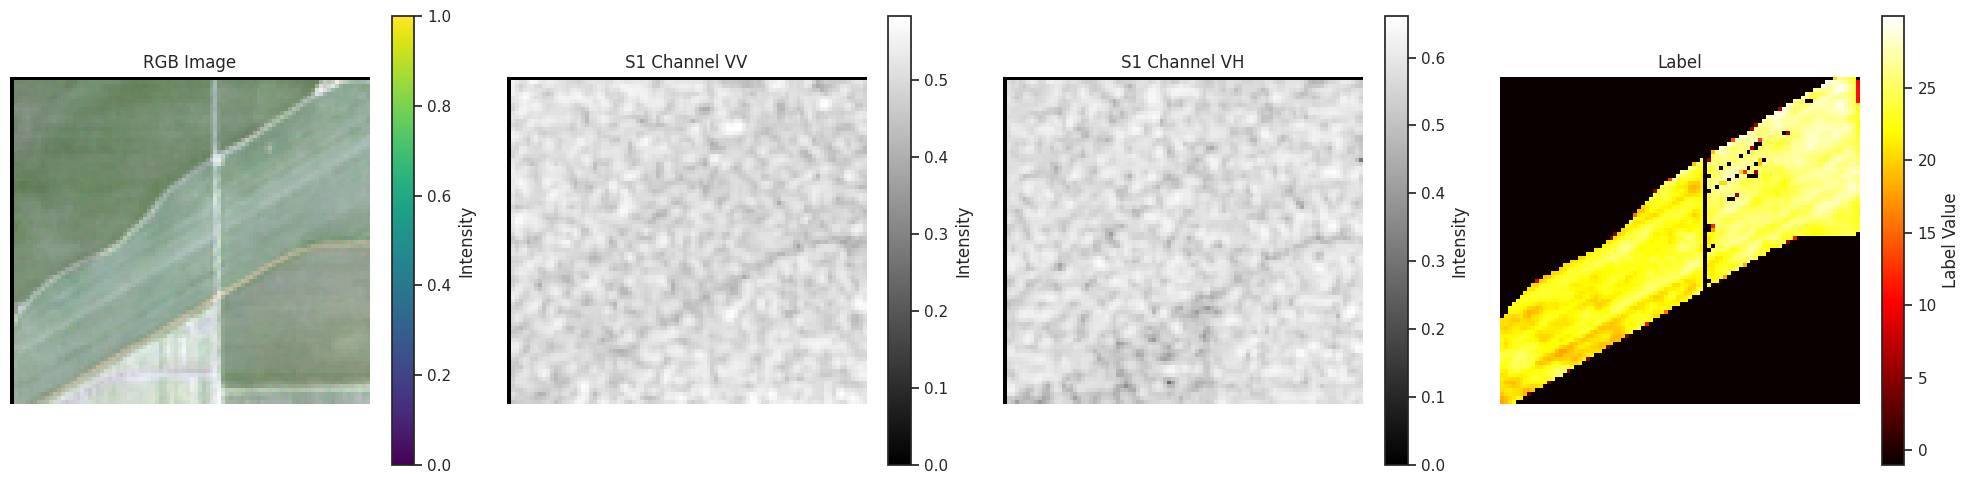

In [37]:
n19 = df_grouped.get_group(group_names[19])
plot_images(n19)

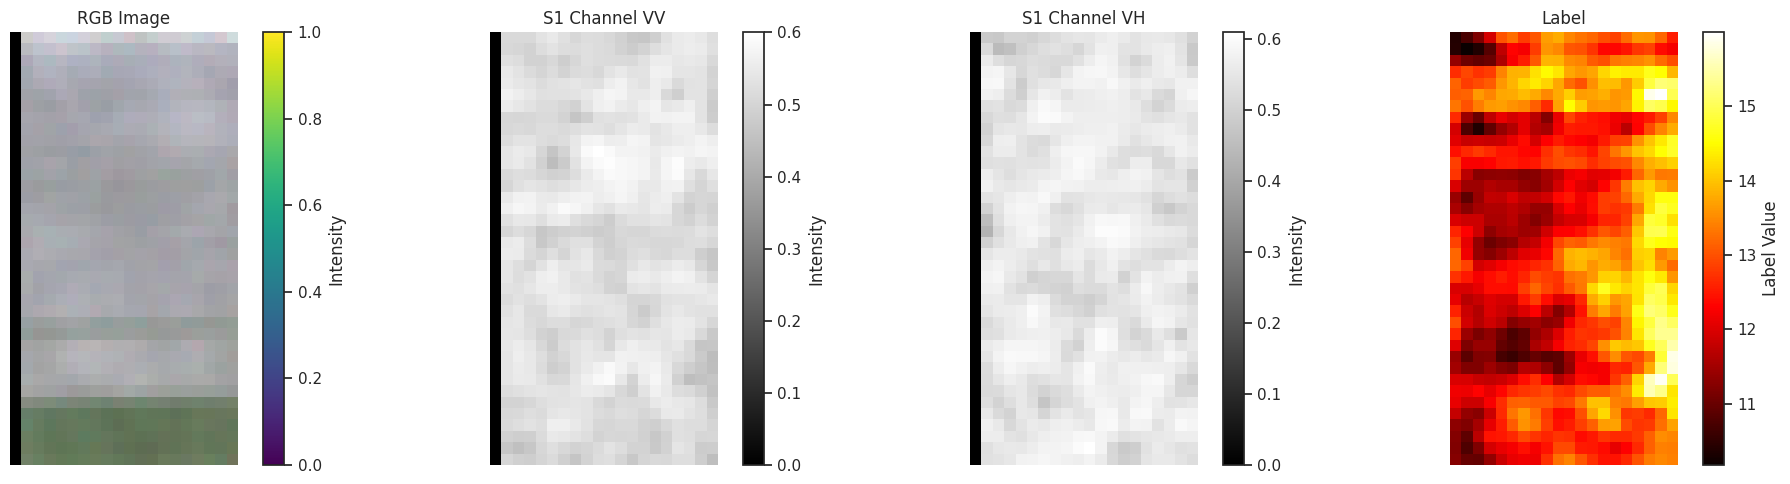

In [38]:
n20 = df_grouped.get_group(group_names[20])
plot_images(n20)

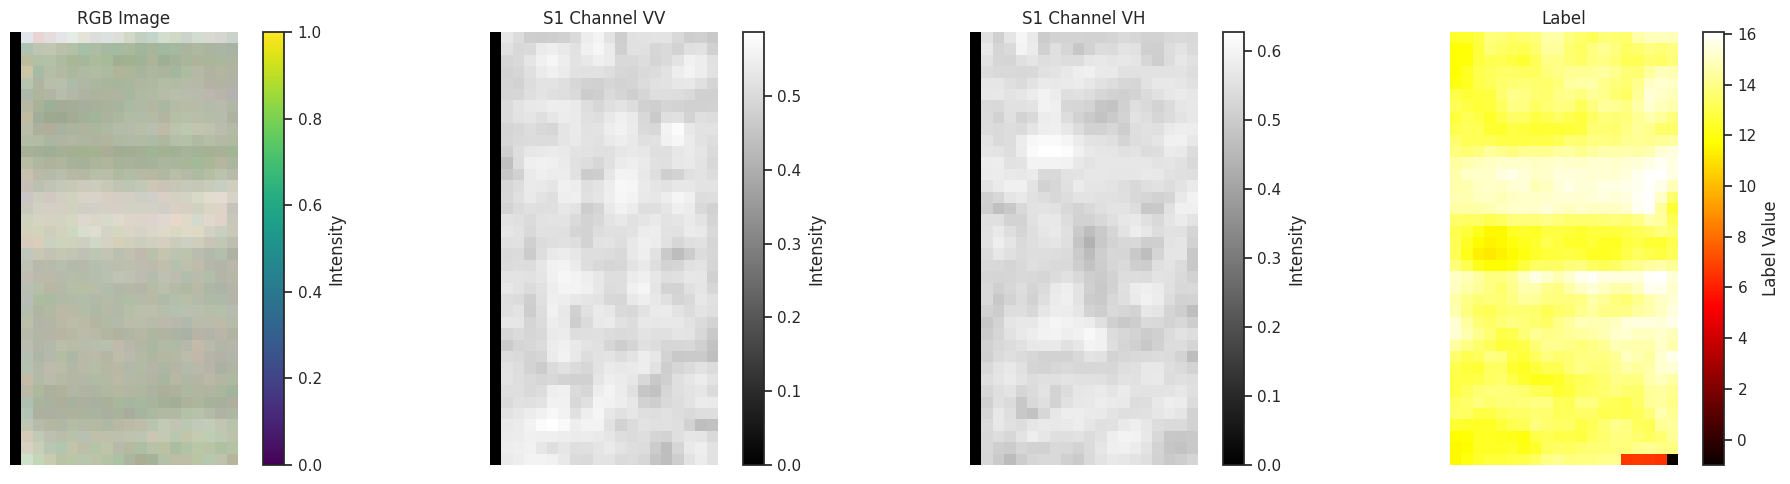

In [12]:
n21 = df_grouped.get_group(group_names[21])
plot_images(n21)

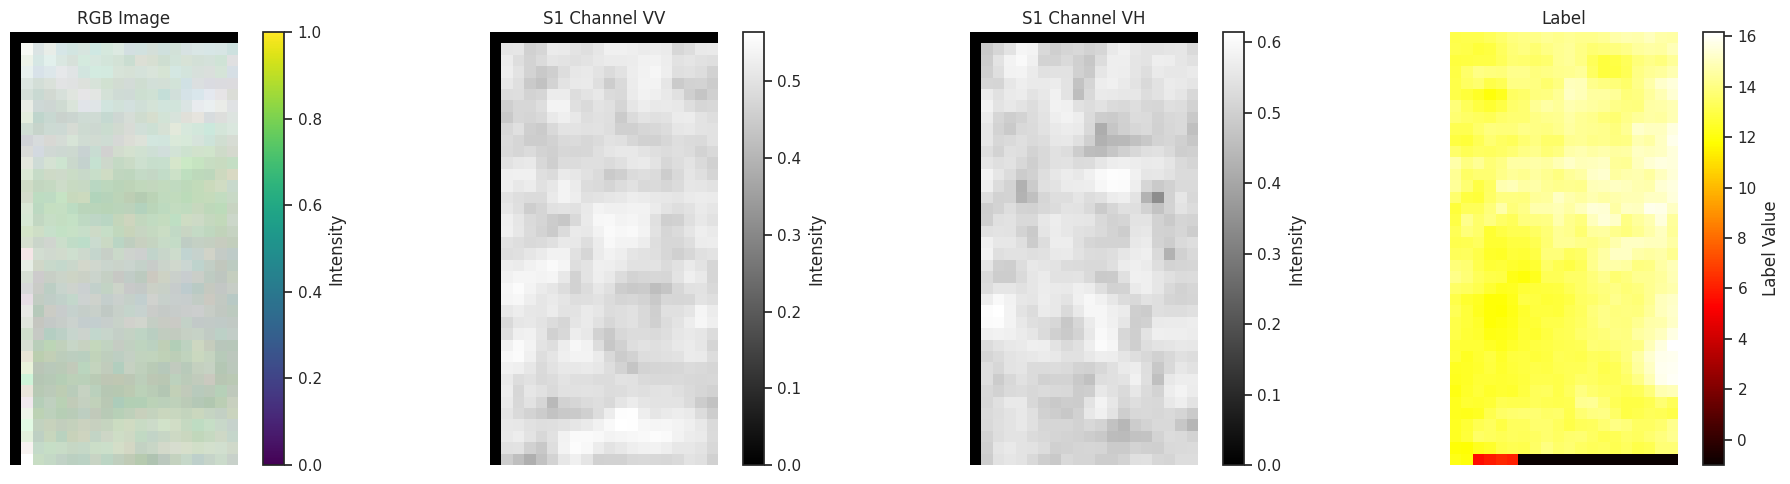

In [40]:
n22 = df_grouped.get_group(group_names[22])
plot_images(n22)

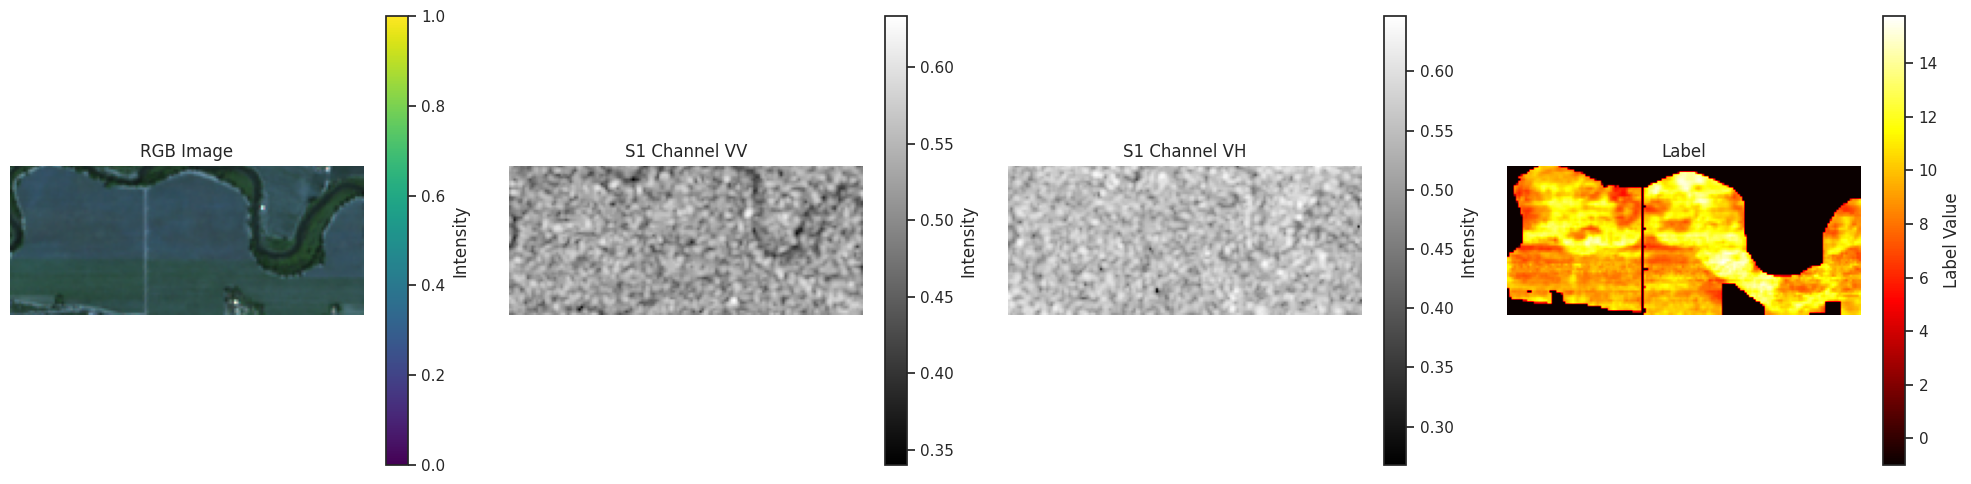

In [41]:
n23 = df_grouped.get_group(group_names[23])
plot_images(n23)

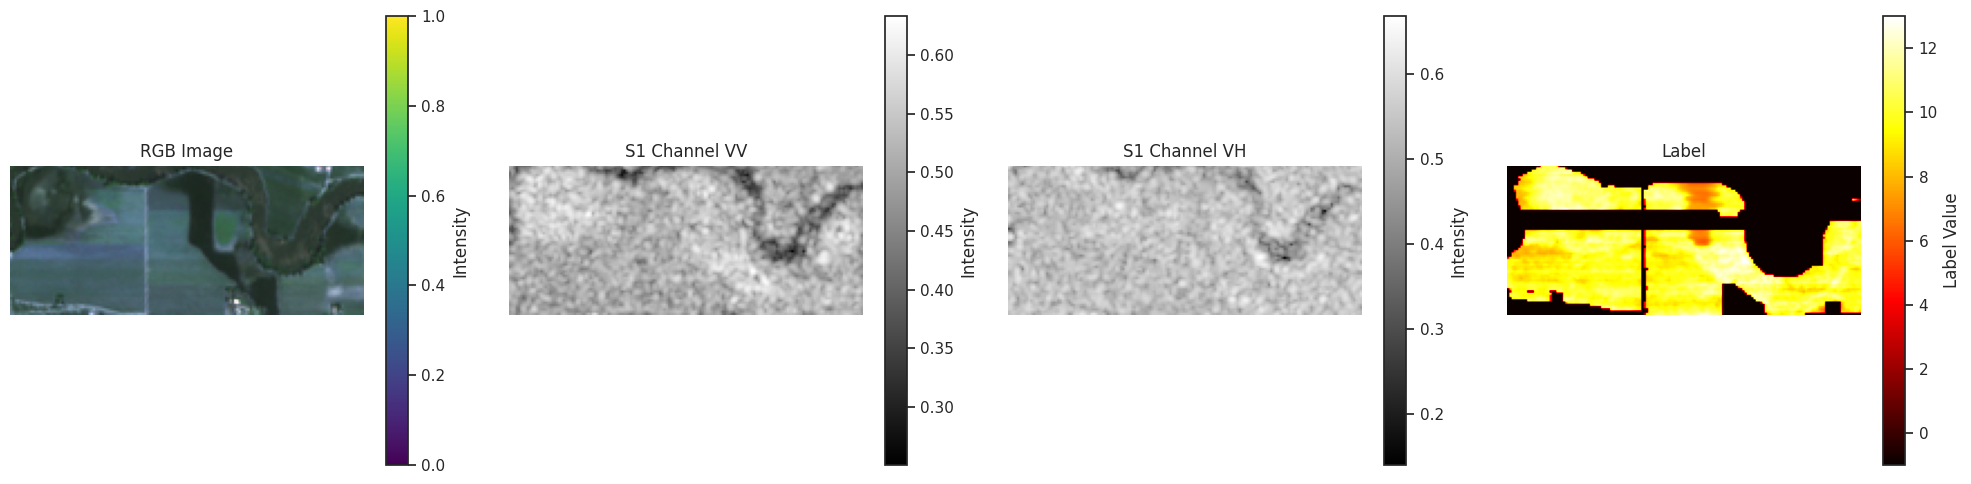

In [13]:
n24 = df_grouped.get_group(group_names[24])
plot_images(n24)

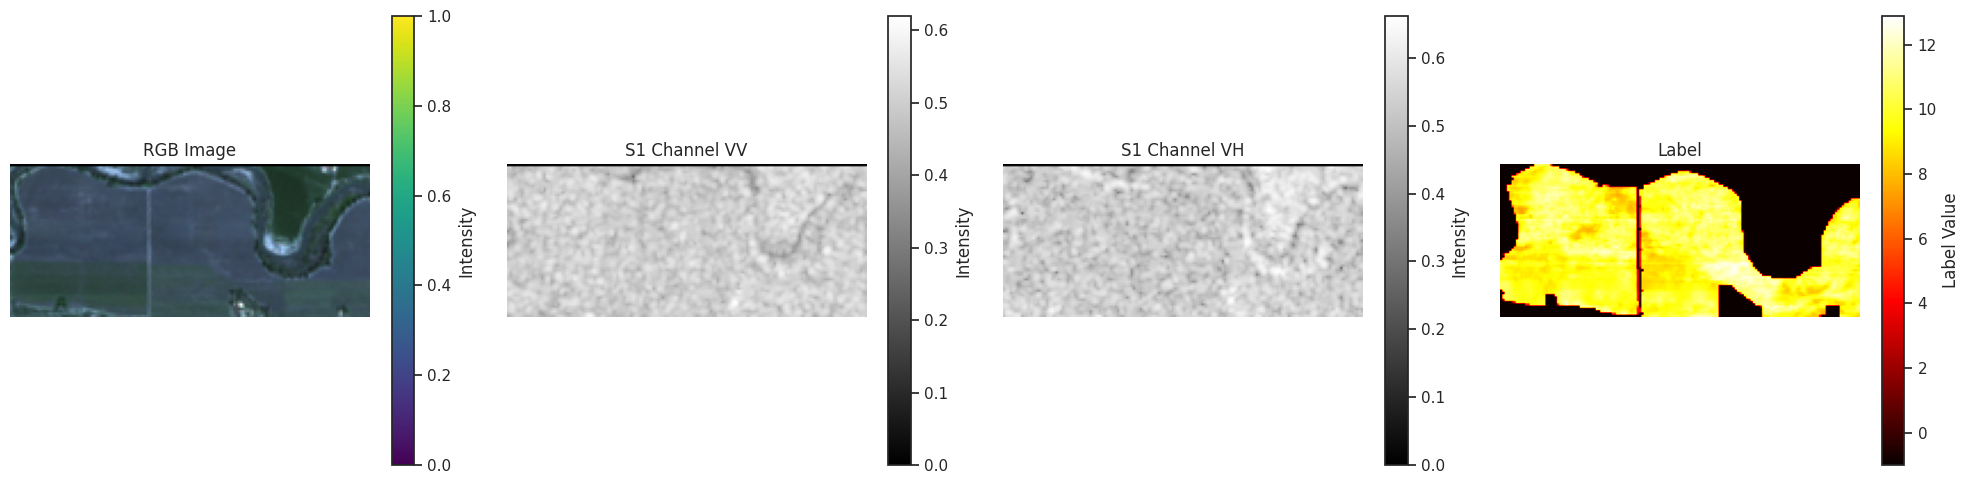

In [43]:
n25 = df_grouped.get_group(group_names[25])
plot_images(n25)

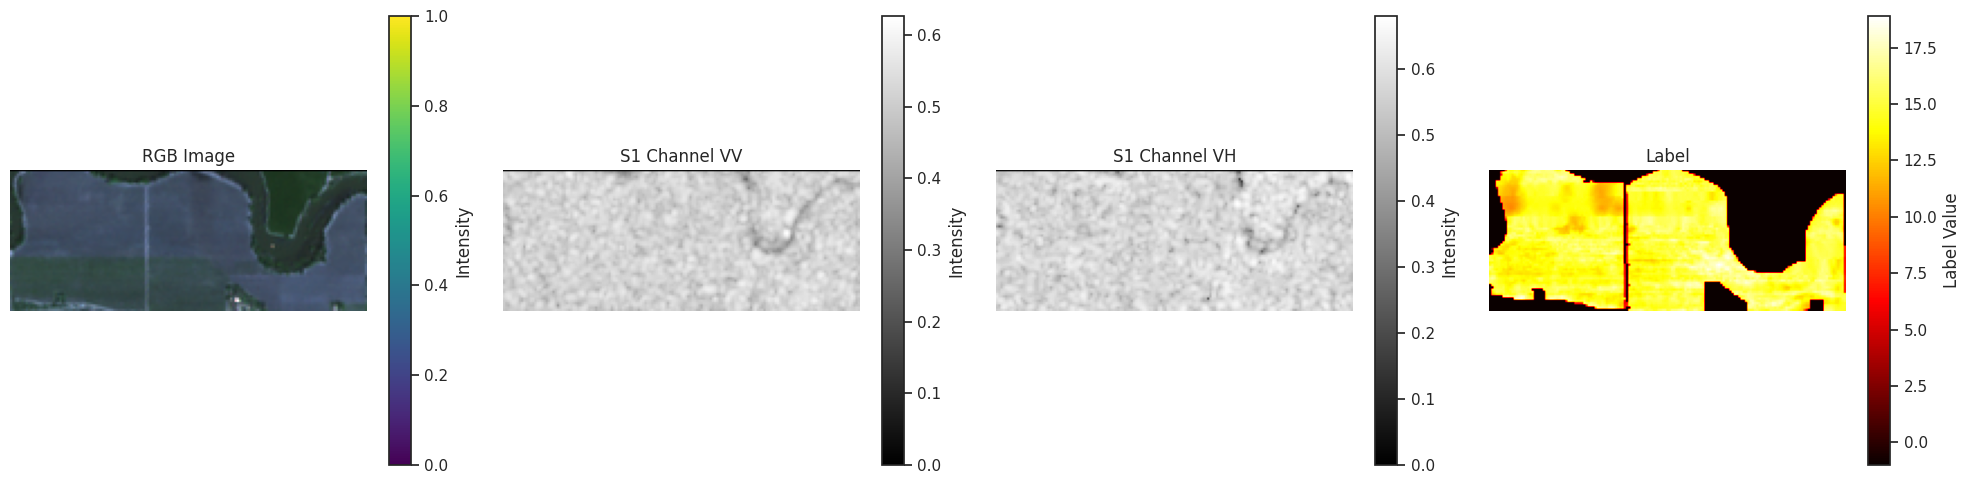

In [44]:
n26 = df_grouped.get_group(group_names[26])
plot_images(n26)

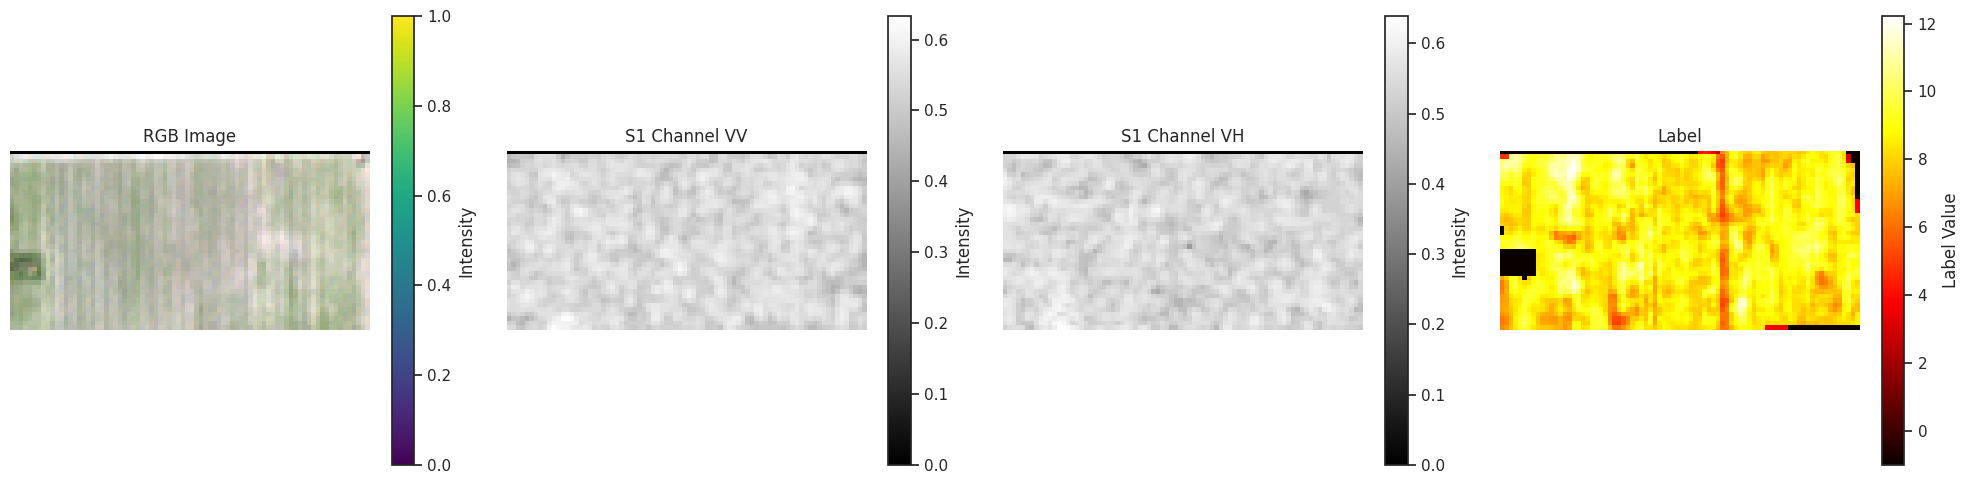

In [45]:
n27 = df_grouped.get_group(group_names[27])
plot_images(n27)

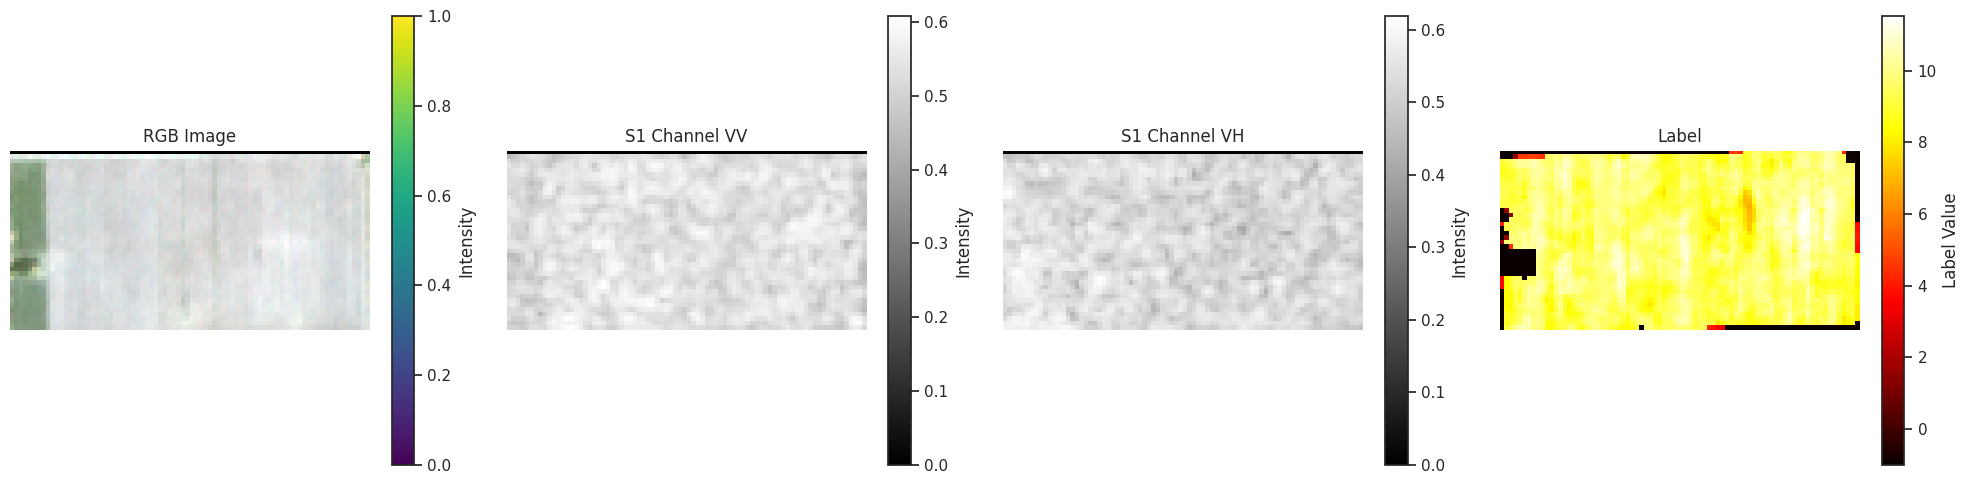

In [14]:
n28 = df_grouped.get_group(group_names[28])
plot_images(n28)

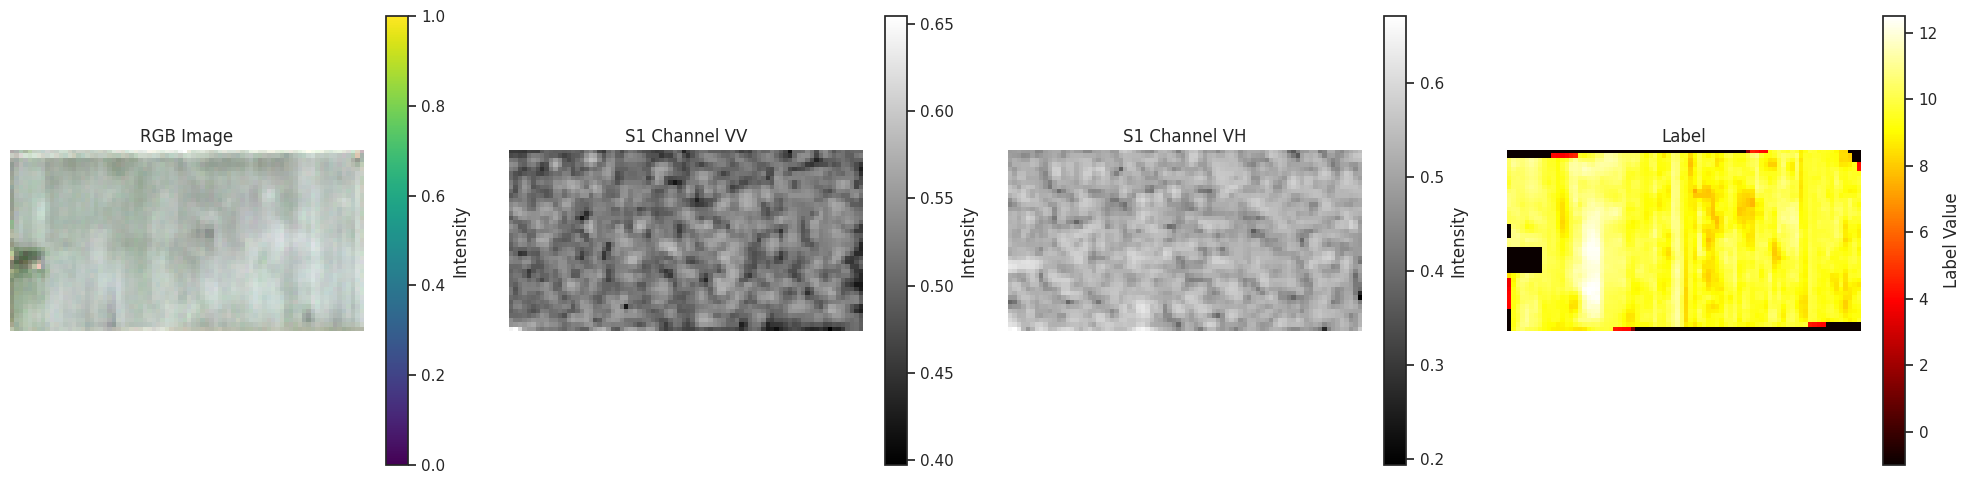

In [47]:
n29 = df_grouped.get_group(group_names[29])
plot_images(n29)

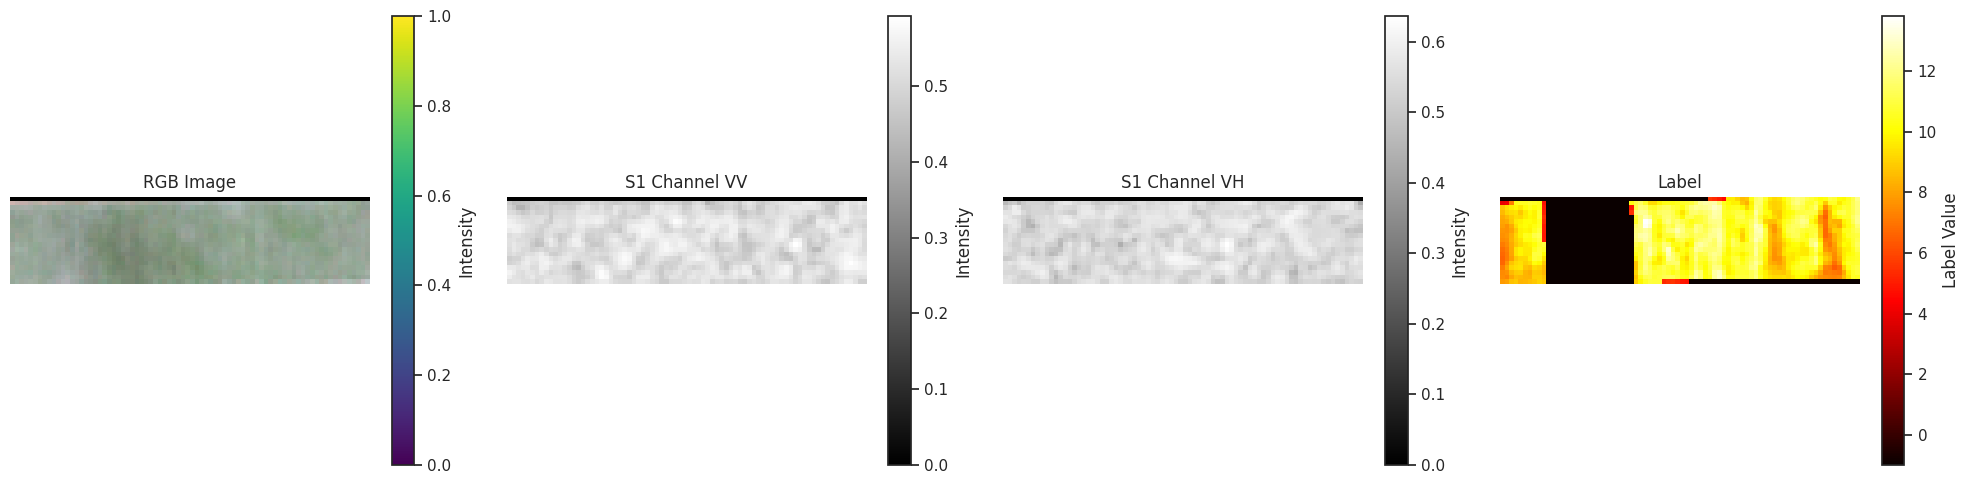

In [48]:
n30 = df_grouped.get_group(group_names[30])
plot_images(n30)

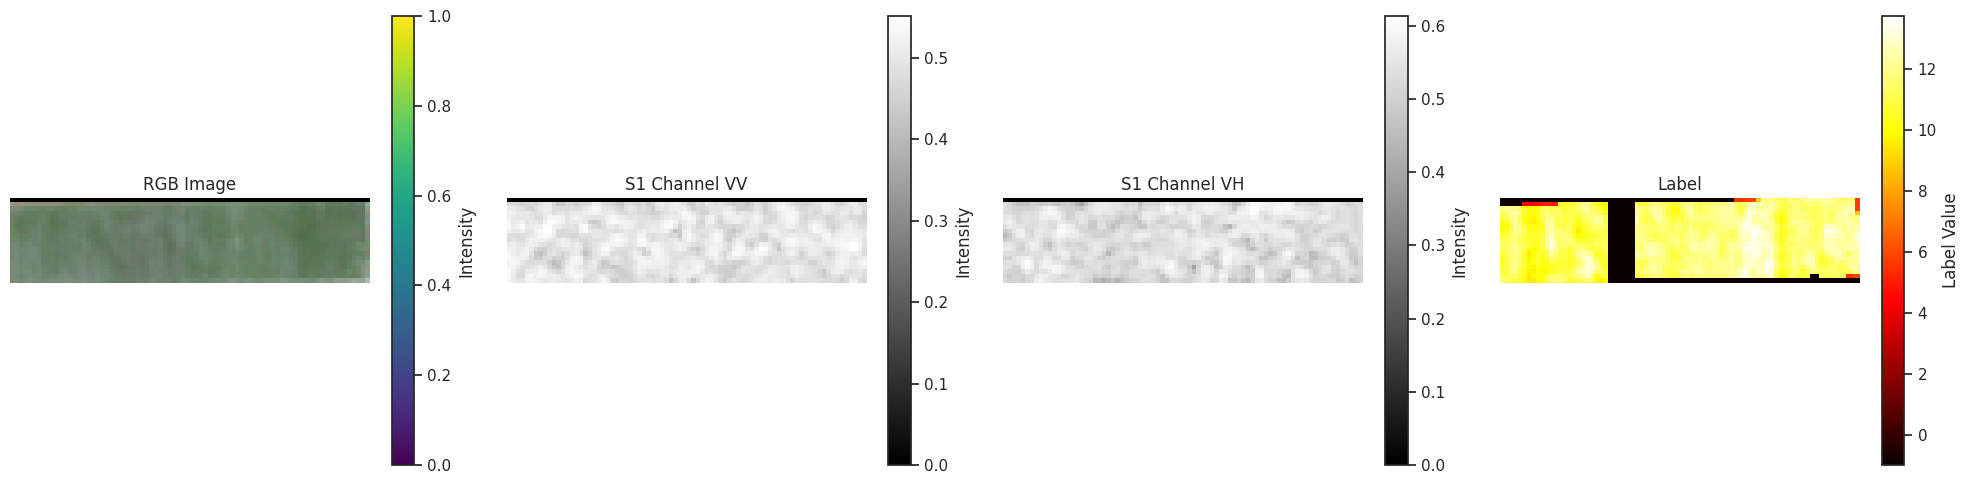

In [15]:
n31 = df_grouped.get_group(group_names[31])
plot_images(n31)

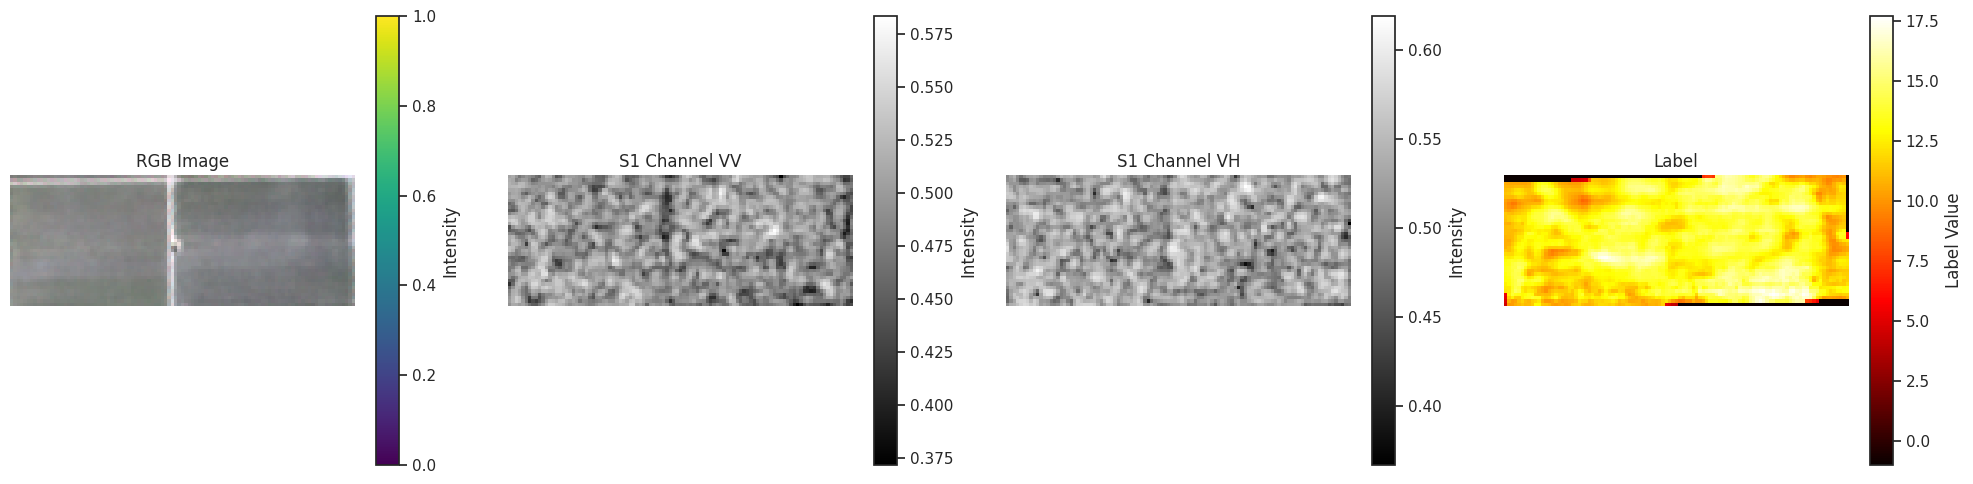

In [50]:
n32 = df_grouped.get_group(group_names[32])
plot_images(n32)

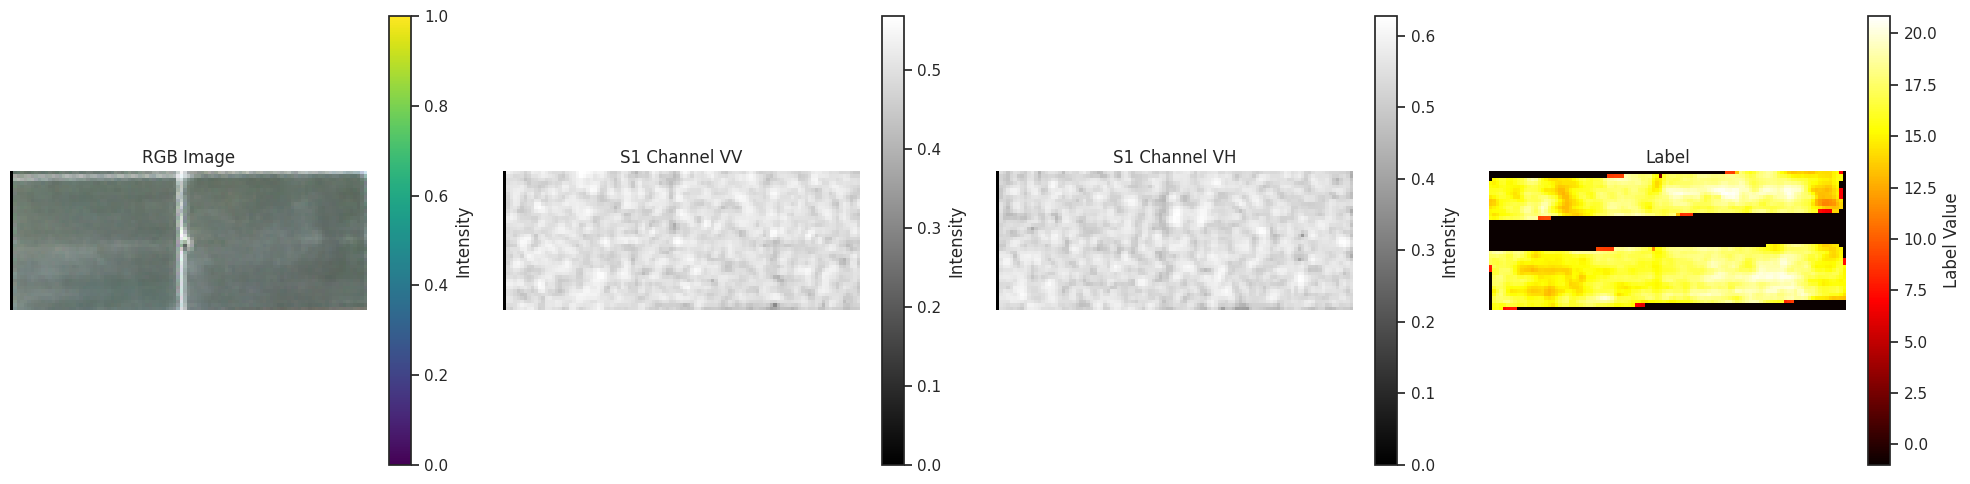

In [16]:
n33 = df_grouped.get_group(group_names[33])
plot_images(n33)

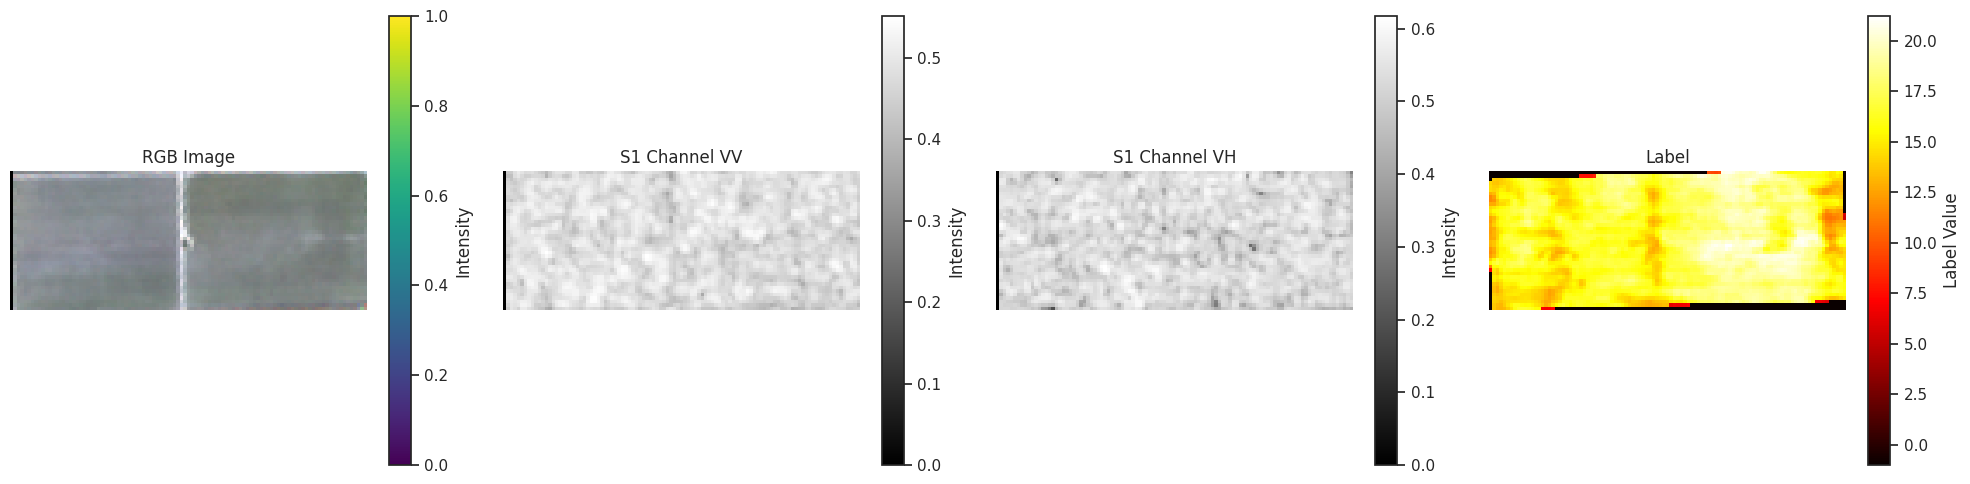

In [52]:
n34 = df_grouped.get_group(group_names[34])
plot_images(n34)

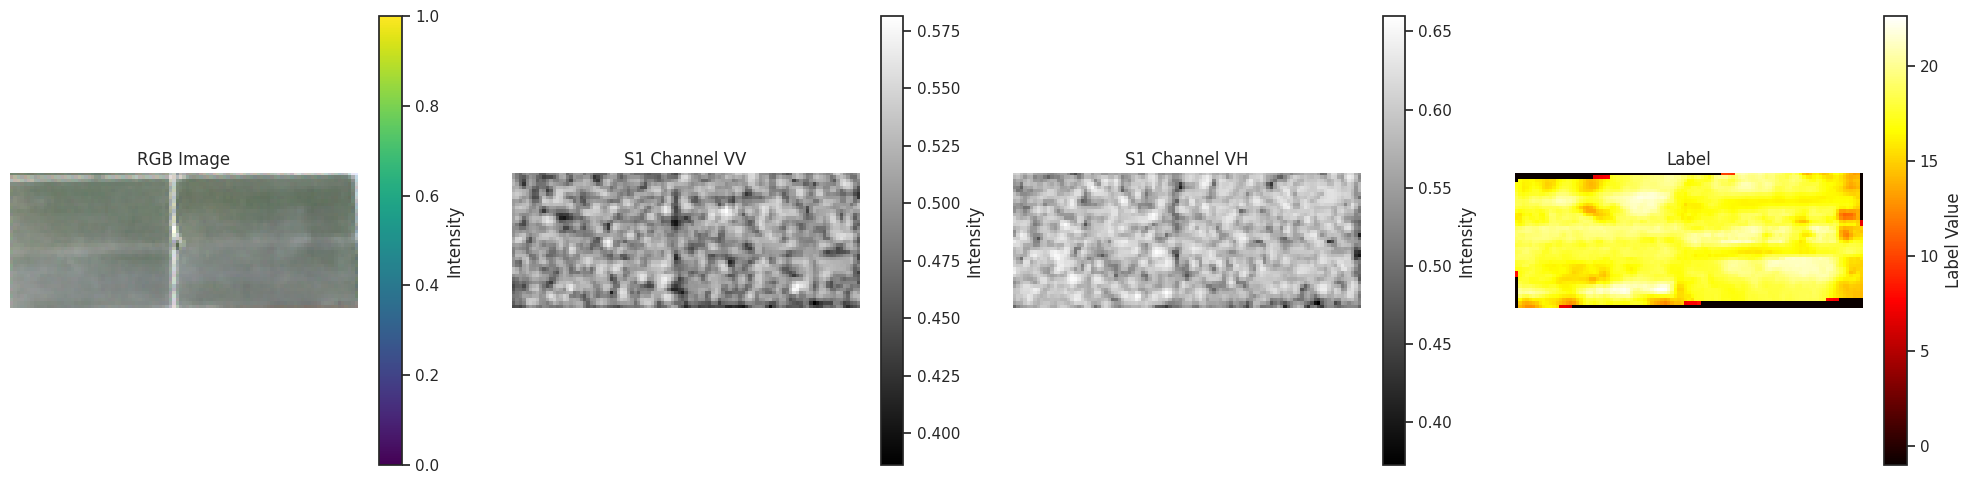

In [53]:
n35 = df_grouped.get_group(group_names[35])
plot_images(n35)

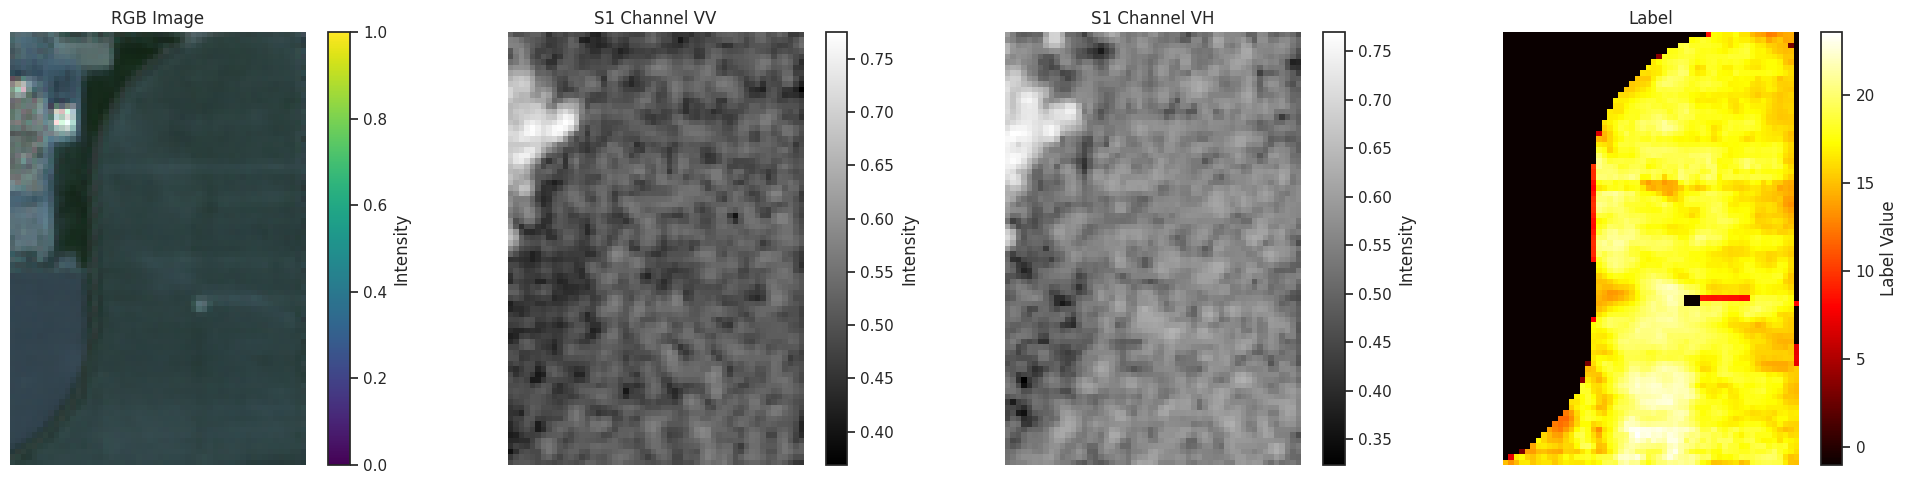

In [54]:
n36 = df_grouped.get_group(group_names[36])
plot_images(n36)

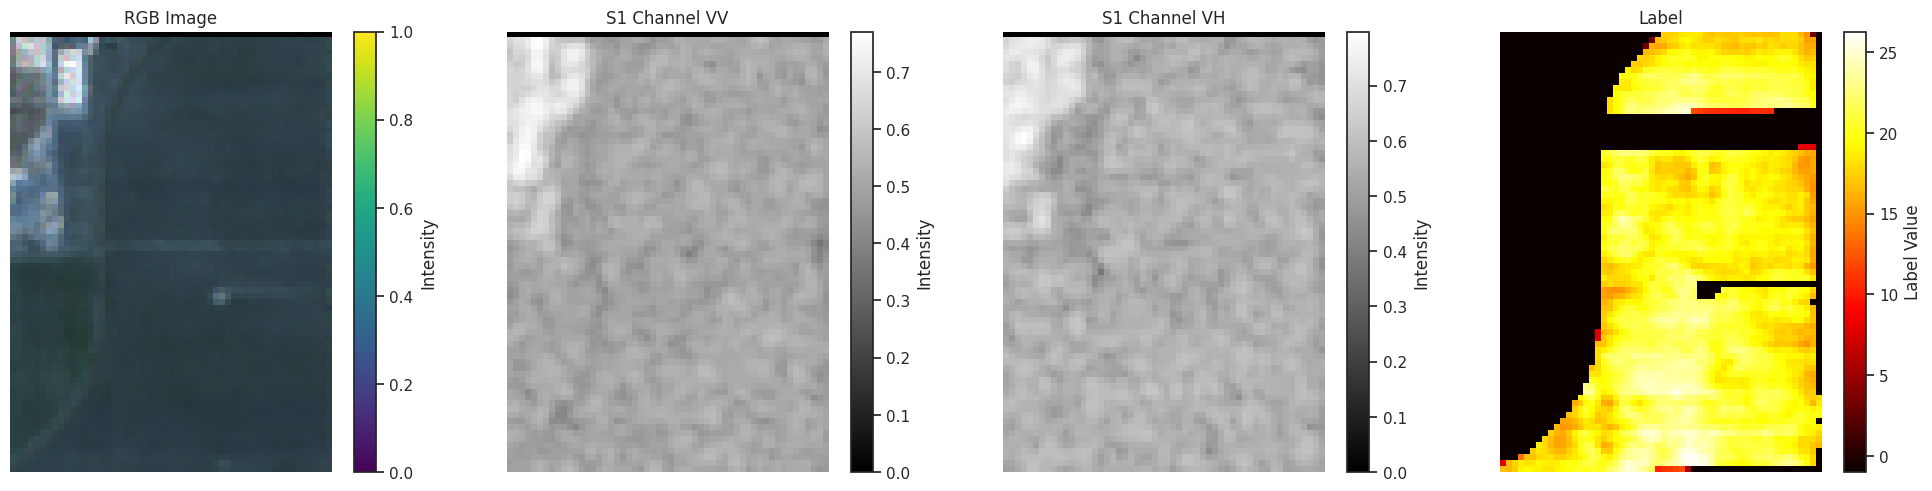

In [17]:
n37 = df_grouped.get_group(group_names[37])
plot_images(n37)

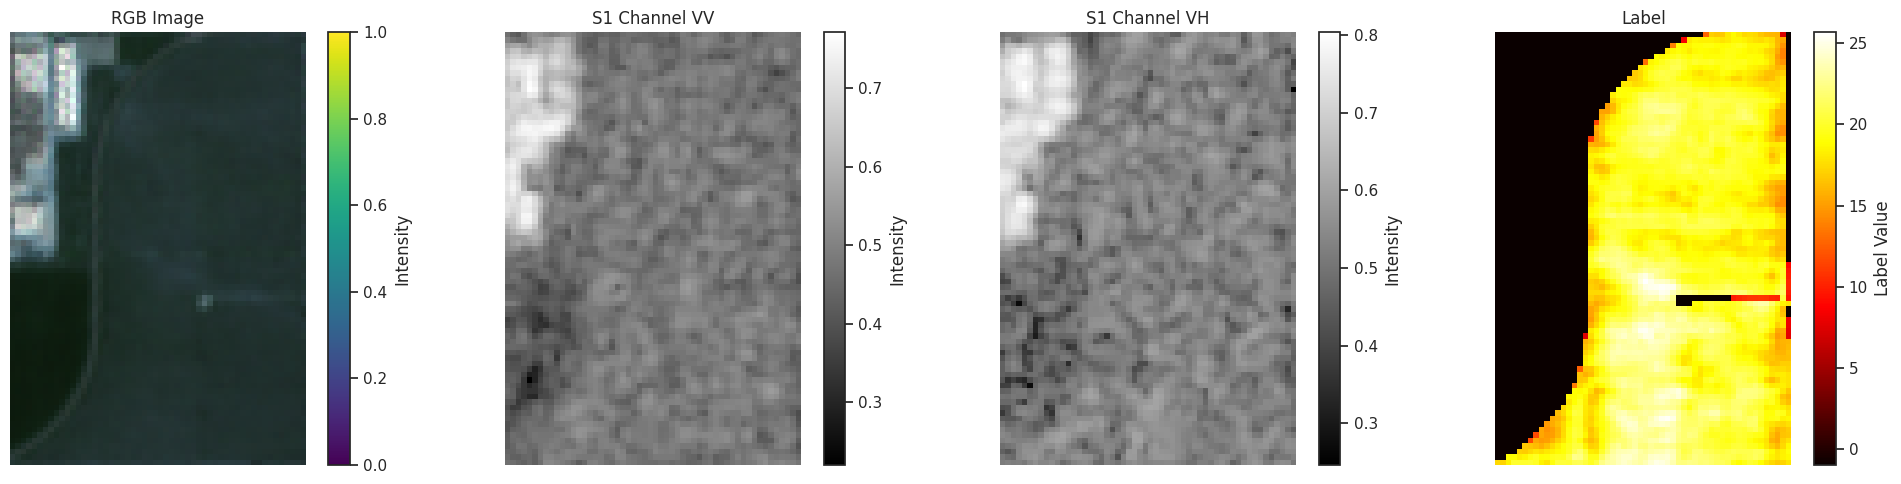

In [56]:
n38 = df_grouped.get_group(group_names[38])
plot_images(n38)

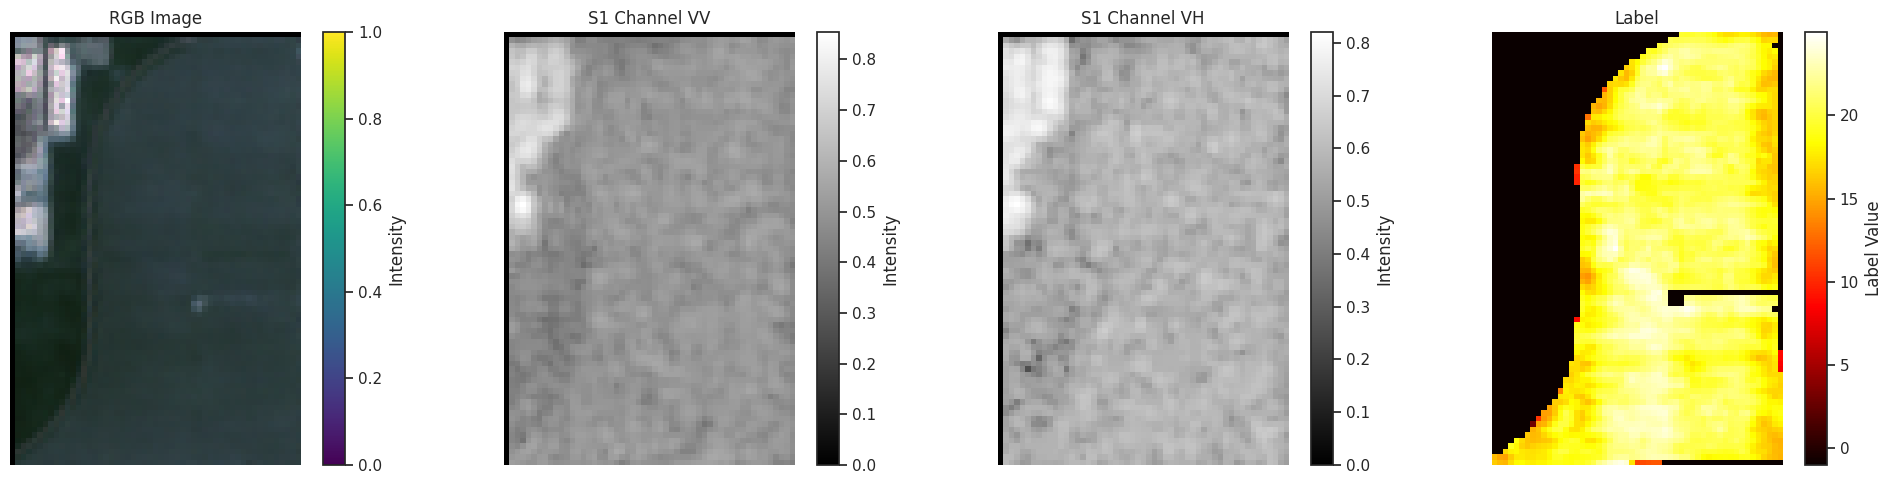

In [57]:
n39 = df_grouped.get_group(group_names[39])
plot_images(n39)

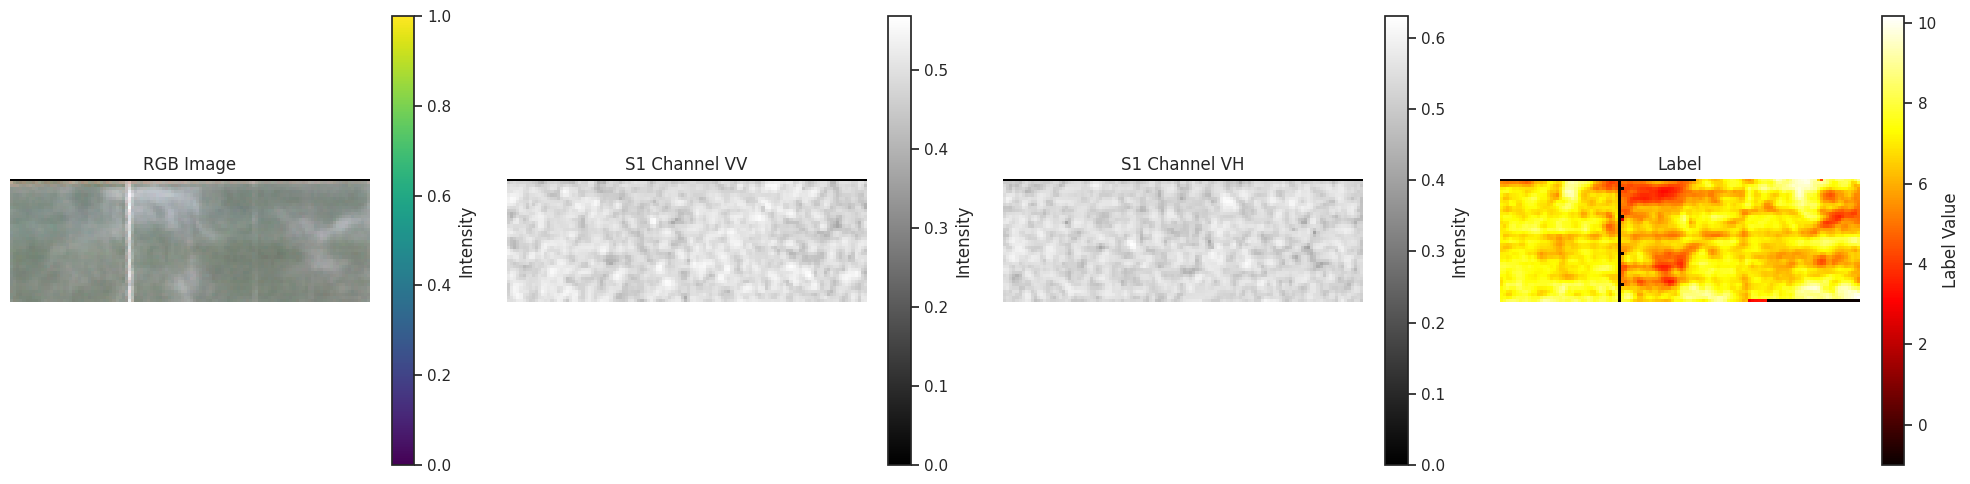

In [58]:
n40 = df_grouped.get_group(group_names[40])
plot_images(n40)

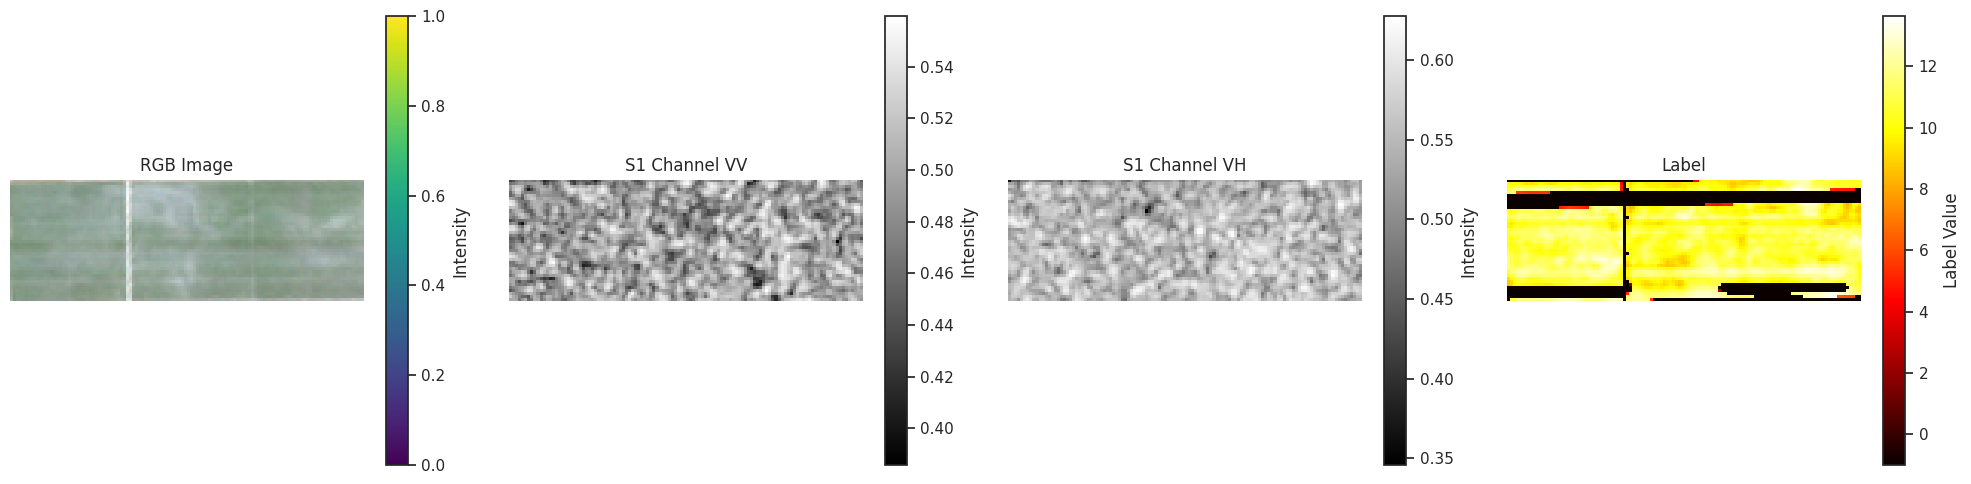

In [18]:
n41 = df_grouped.get_group(group_names[41])
plot_images(n41)

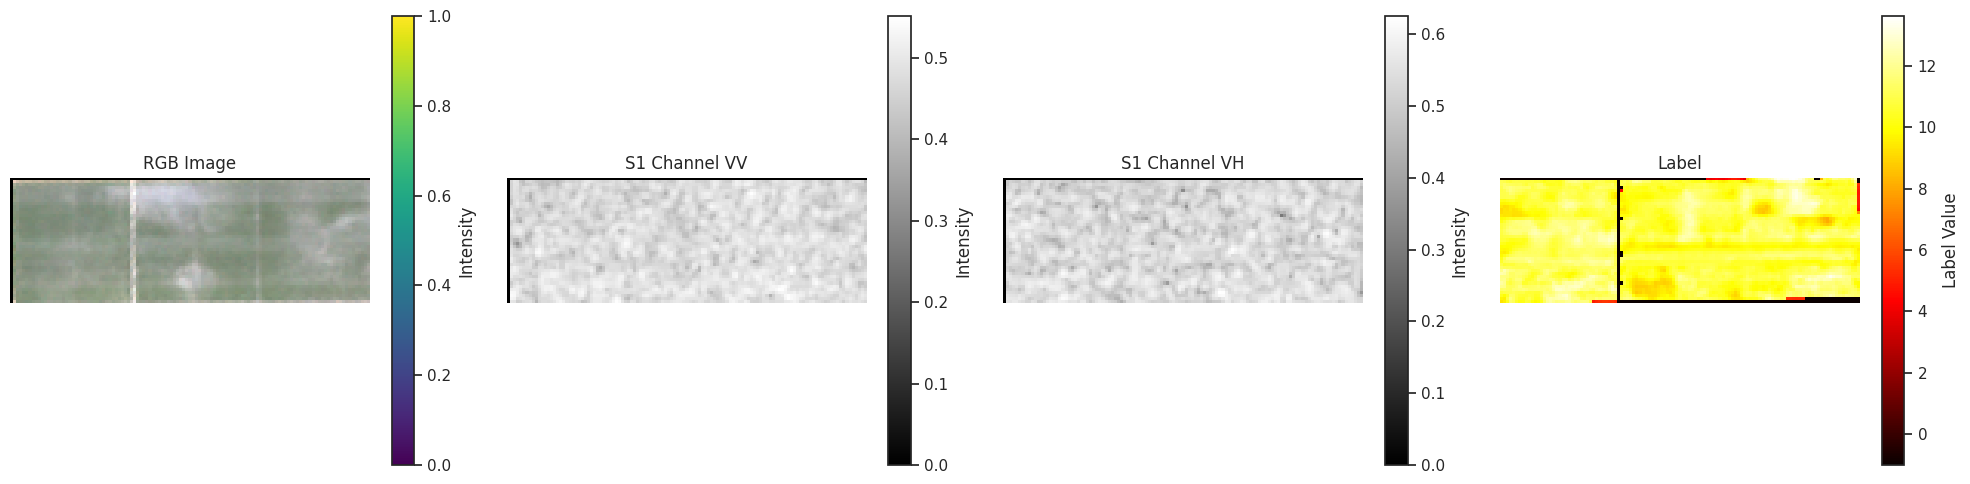

In [19]:
n42 = df_grouped.get_group(group_names[42])
plot_images(n42)

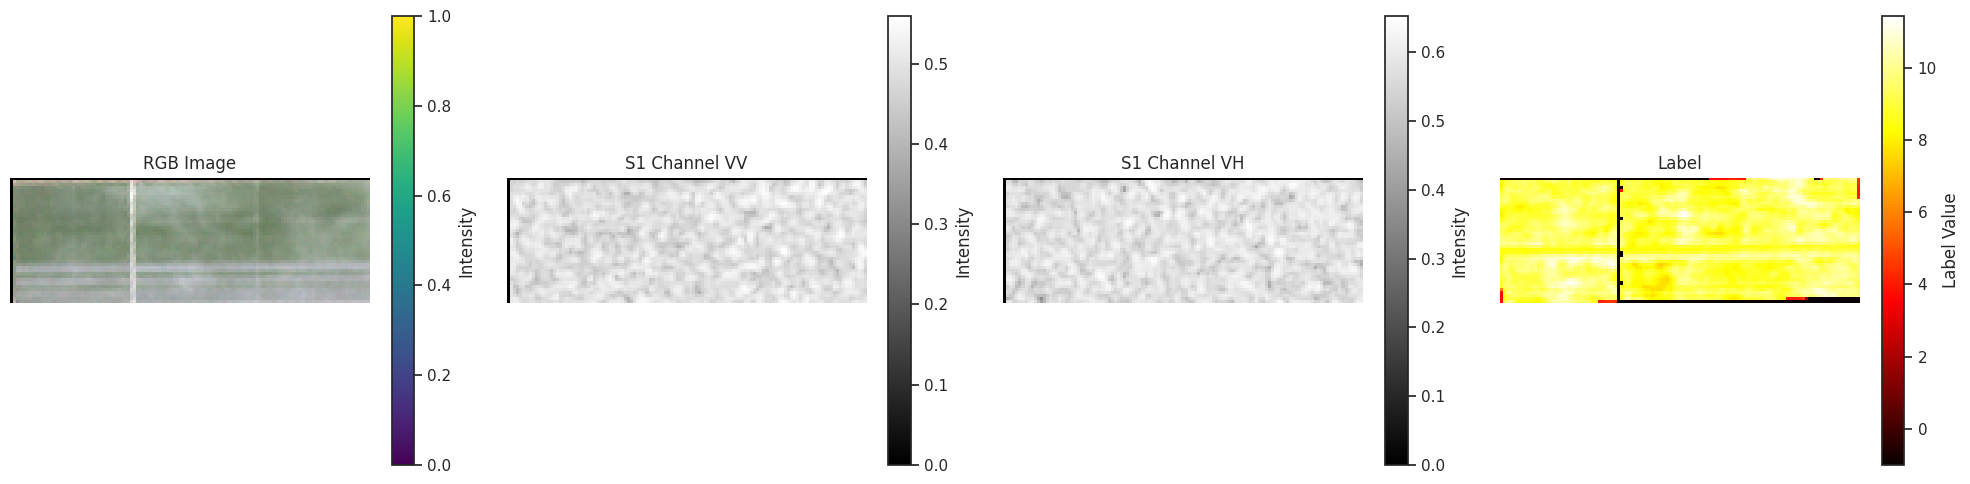

In [61]:
n43 = df_grouped.get_group(group_names[43])
plot_images(n43)

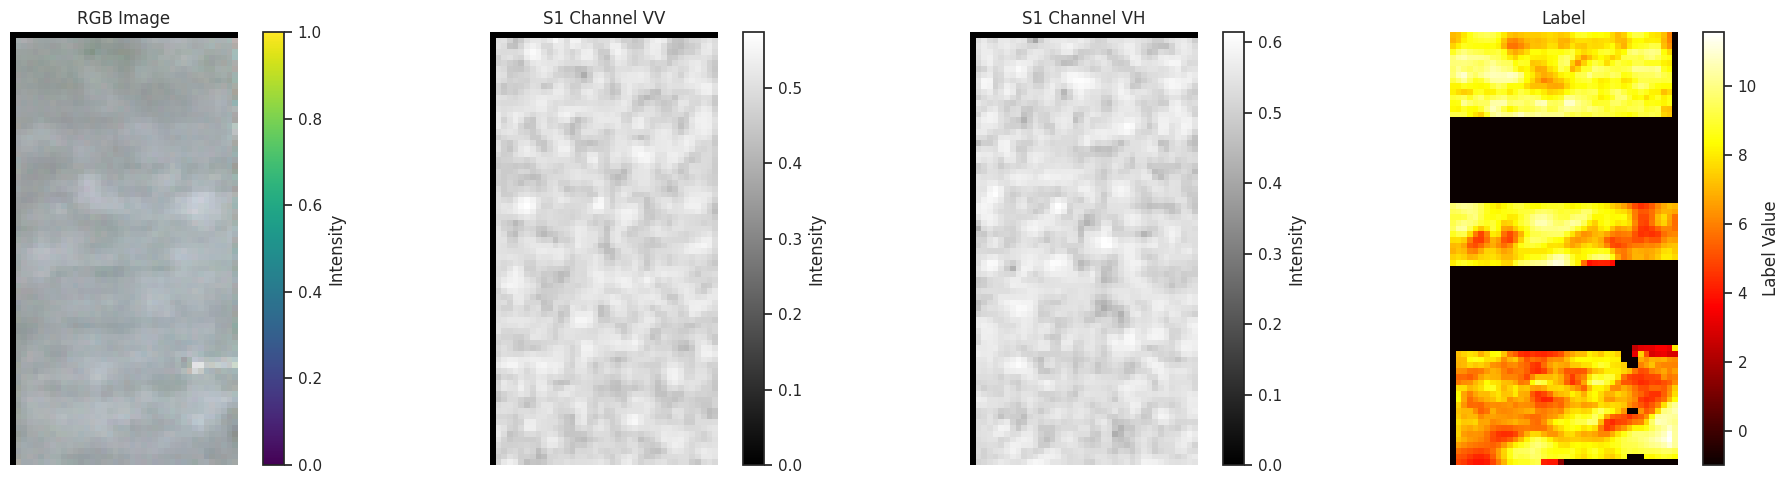

In [62]:
n44 = df_grouped.get_group(group_names[44])
plot_images(n44)

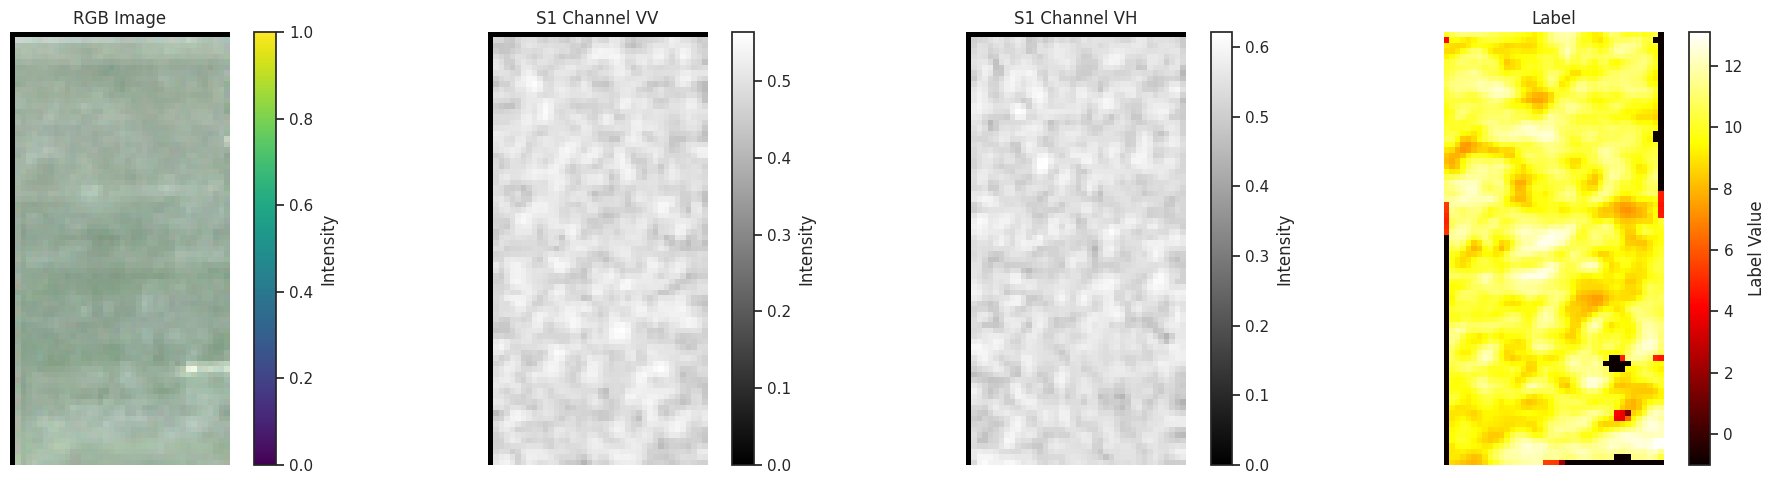

In [20]:
n45 = df_grouped.get_group(group_names[45])
plot_images(n45)

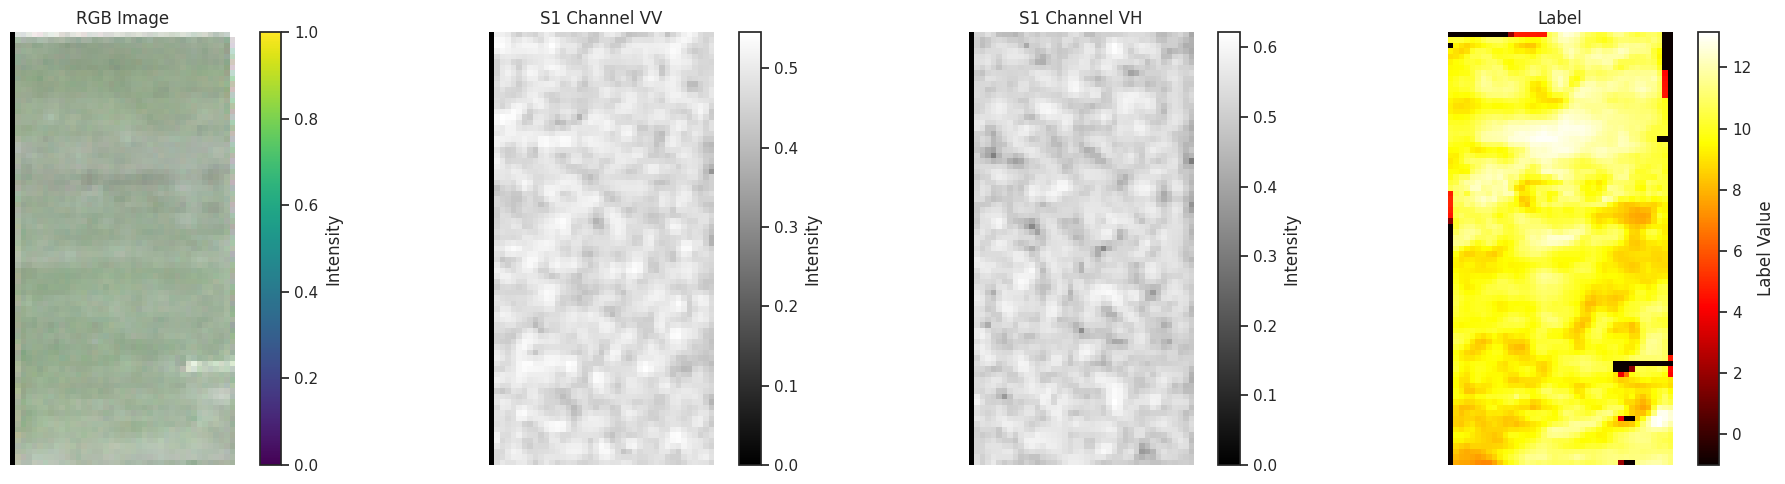

In [64]:
n46 = df_grouped.get_group(group_names[46])
plot_images(n46)

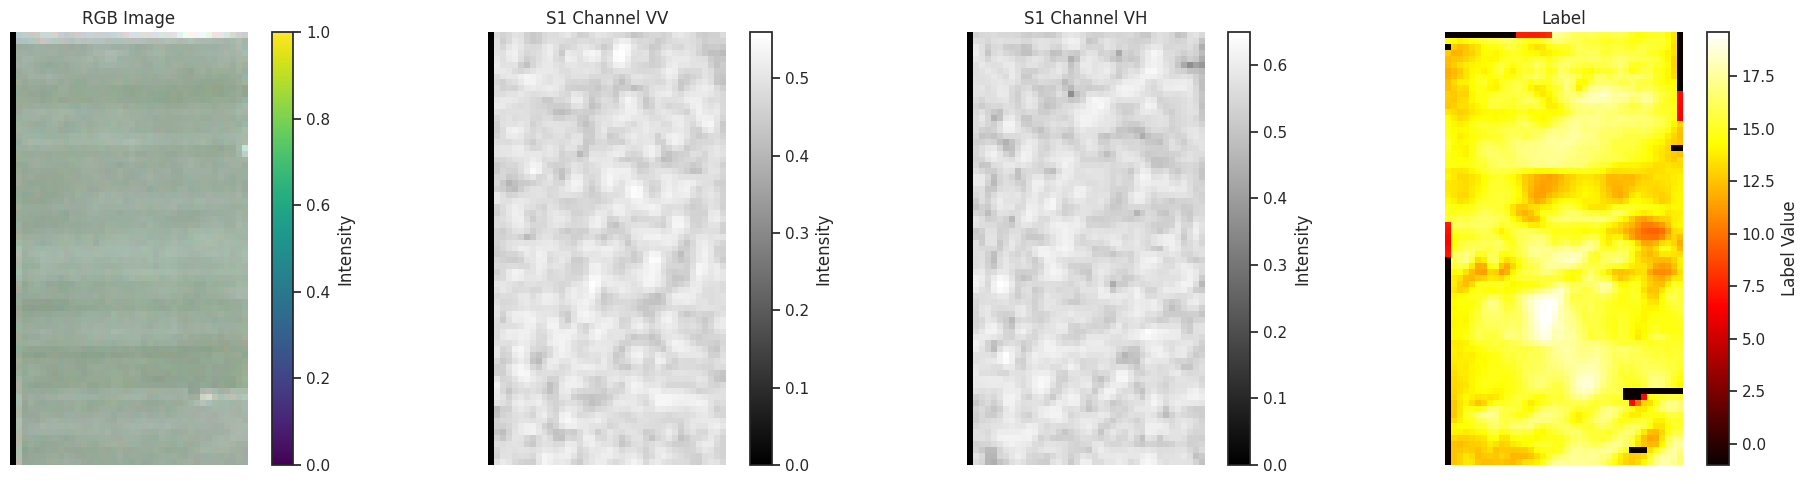

In [65]:
n47 = df_grouped.get_group(group_names[47])
plot_images(n47)

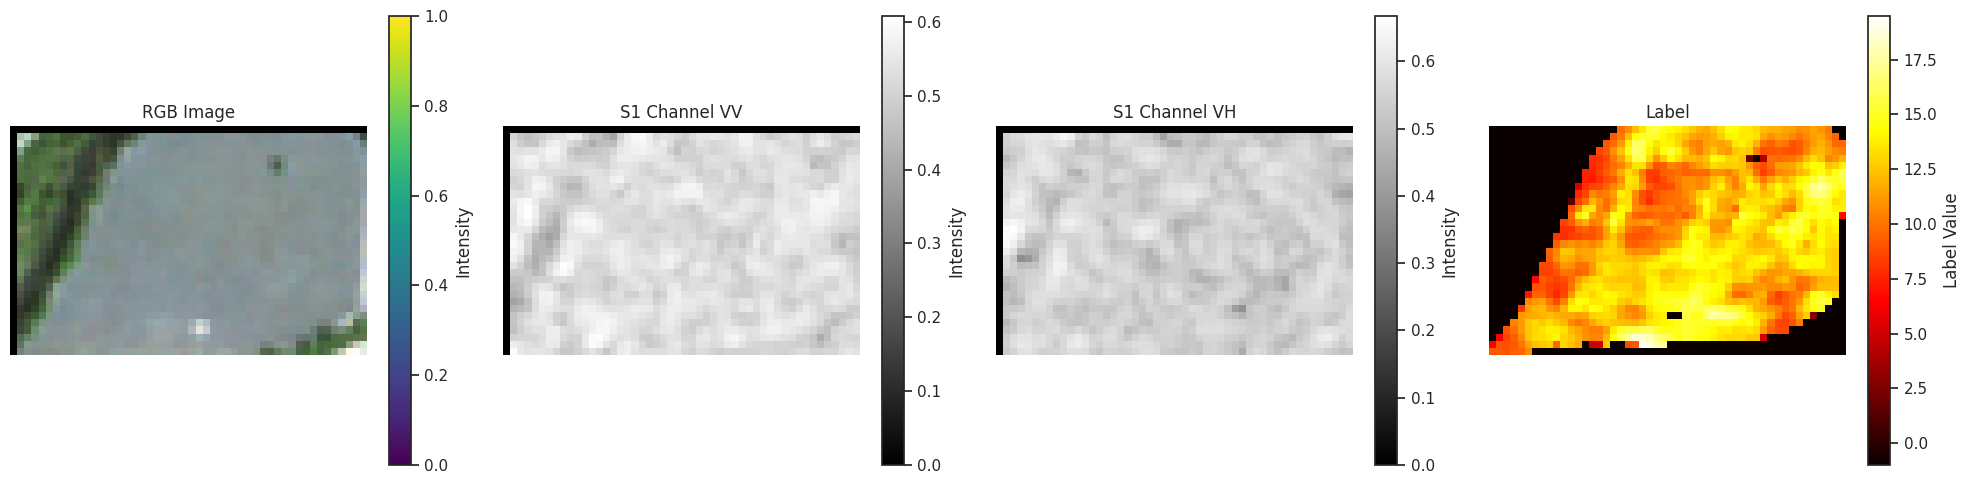

In [66]:
n48 = df_grouped.get_group(group_names[48])
plot_images(n48)

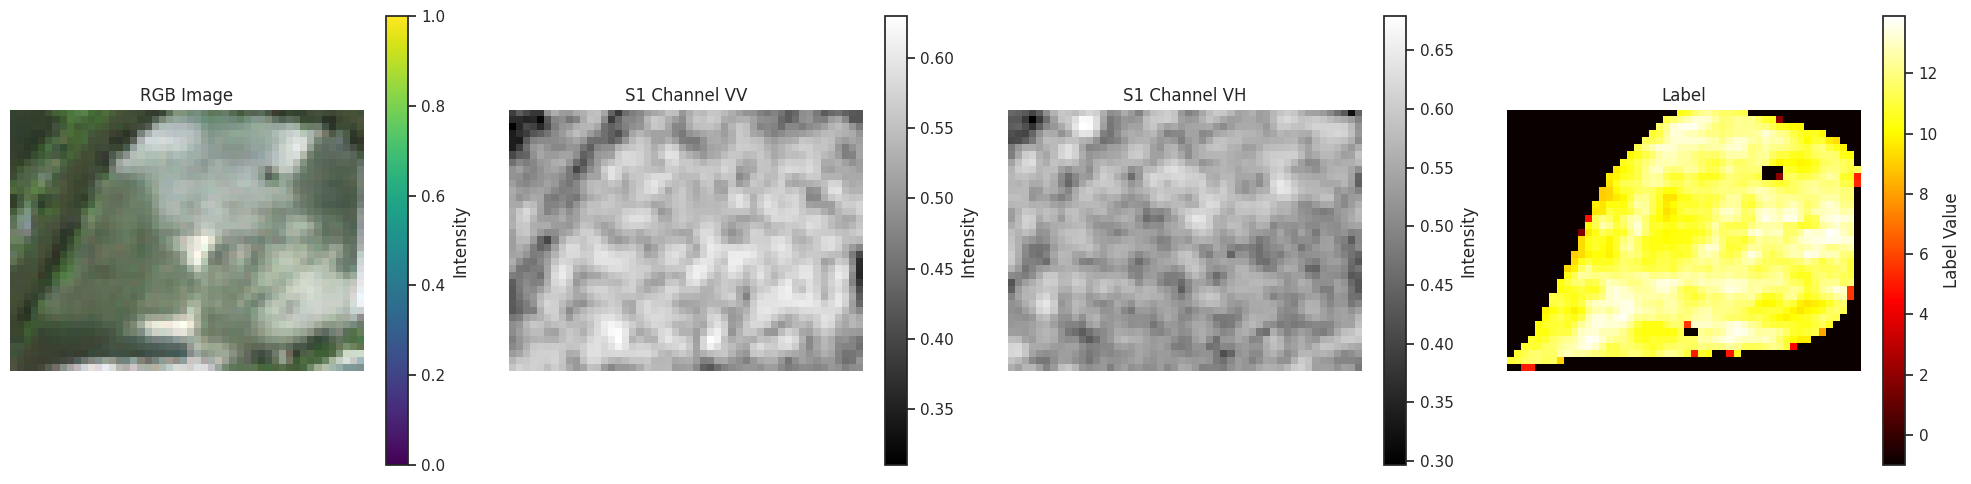

In [21]:
n49 = df_grouped.get_group(group_names[49])
plot_images(n49)

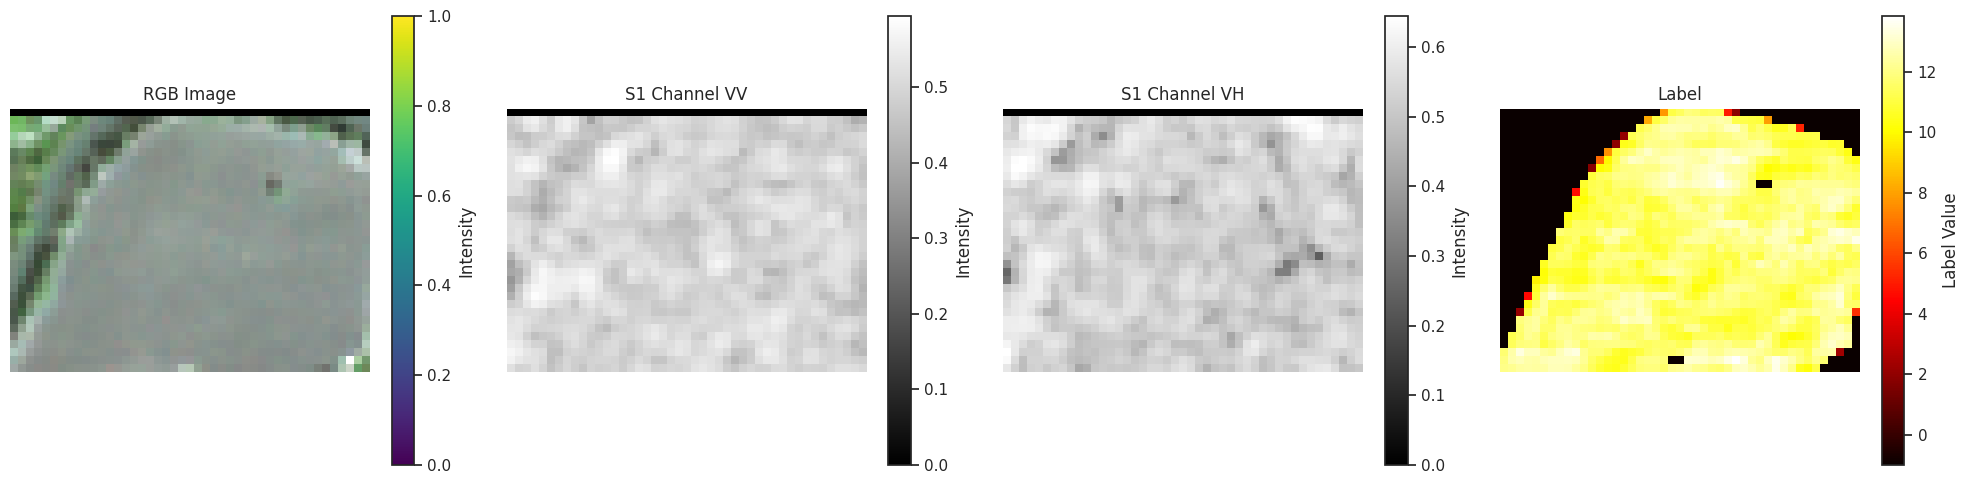

In [68]:
n50 = df_grouped.get_group(group_names[50])
plot_images(n50)

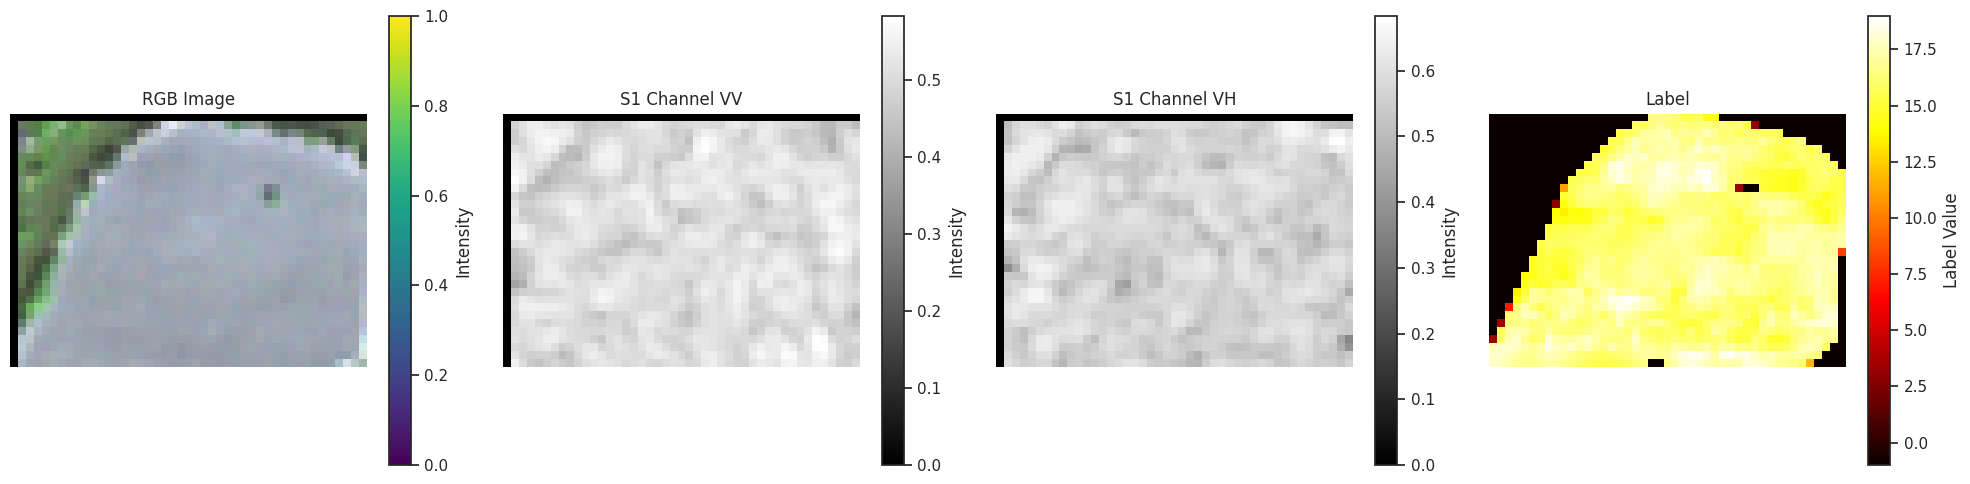

In [69]:
n51 = df_grouped.get_group(group_names[51])
plot_images(n51)

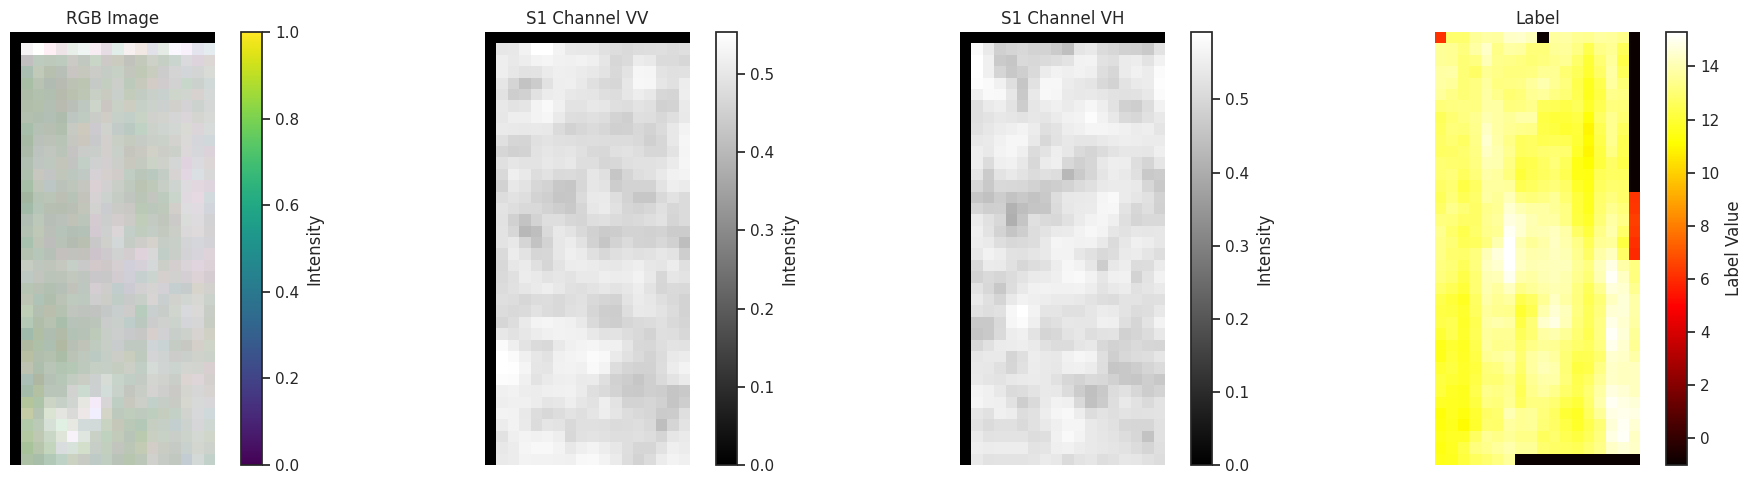

In [22]:
n52 = df_grouped.get_group(group_names[52])
plot_images(n52)

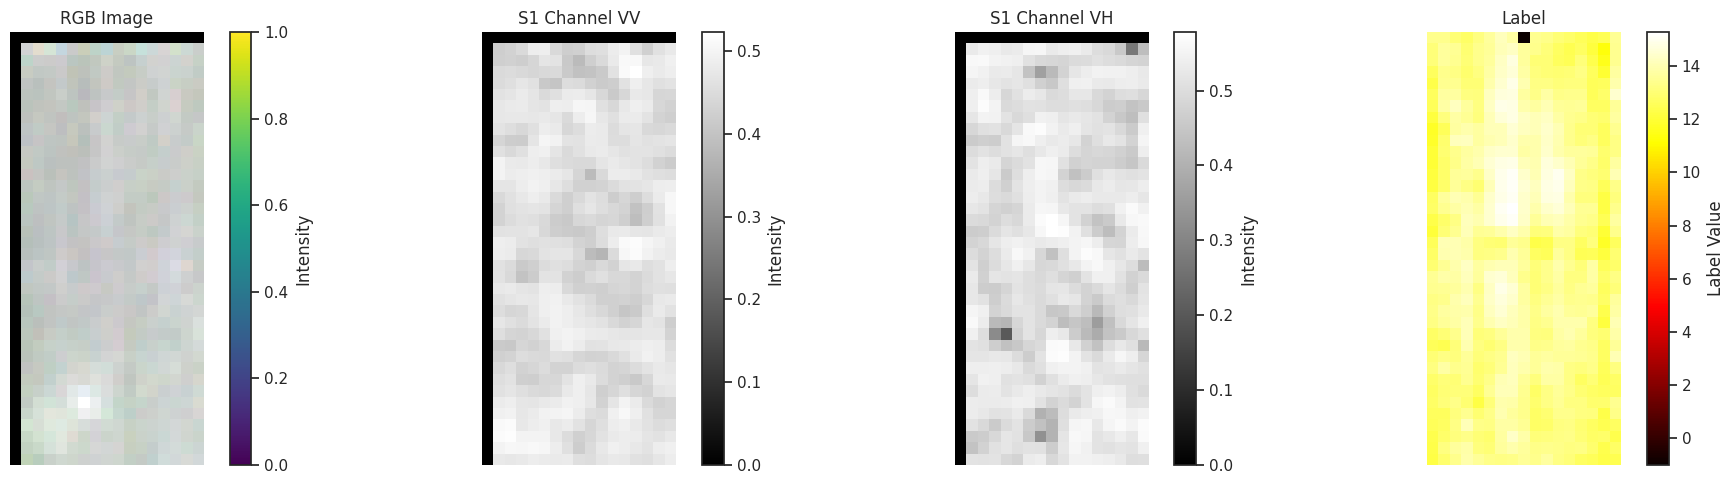

In [71]:
n53 = df_grouped.get_group(group_names[53])
plot_images(n53)

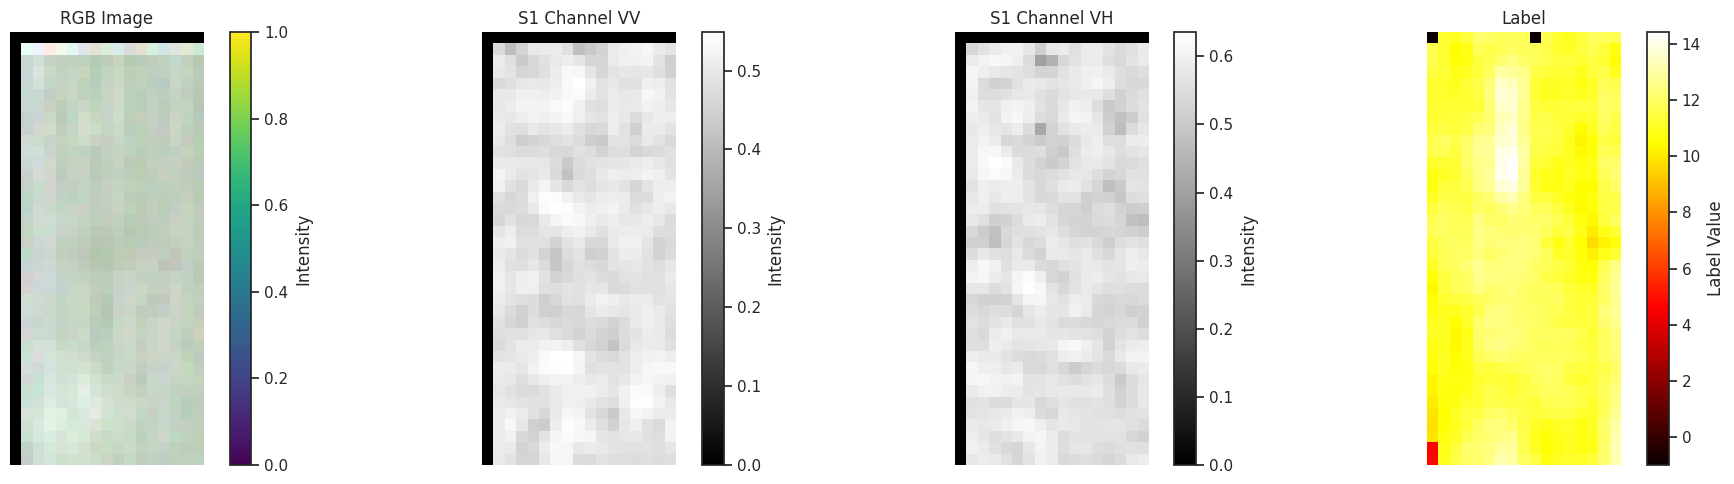

In [72]:
n54 = df_grouped.get_group(group_names[54])
plot_images(n54)